# <i><b>This notebook is for Preliminarly Exploratory Data Analysis of the Fraud Data set...

## <b><i> Initial Numeric Exploratory Data Analysis of the fraud data

### <b> 1. Libraries

In [24]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as io
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import chi2_contingency
import plotly.express as px
import missingno as msno
import math


### <b> 2. Load Data


In [2]:
# file path
excel_file_path = Path("C:/Users/HUSTLE/OneDrive/Documentos/panashe.dev/Projects/fraud-detection/data/fraud_dataset_raw.xlsx")

In [3]:
fraud_data = pd.read_excel(excel_file_path)

### <b> 3. Examining the top and bottom part of the fraud data

In [4]:
# First 5 rows
fraud_data.head()

,amount,browser,channel,customer_age,date,fraud,ip,isp,latitude,loginTime,...,onceoff_vs_beneficiary,os,paymentType,region,rtc_indicator,to_acc_volume,to_bank,txn_timestamp,uuid,transactor_id
0,120000.0,Chrome_Some(66),channel_B,51.0,2018-06-01,0,102.253.144.146,TelkomInternet,-29,2018-06-01T19:27:21.000Z,...,B,Windows_Some(7),F,ZA_null,0,18,FNBRMB,2018-06-01T19:46:21.000Z,NaN,9150237
1,1250.0,Chrome_Some(89),channel_B,26.0,2021-04-07,0,197.89.21.227,OPTINET,-26.3811,2021-04-07T16:10:10.000Z,...,B,Windows_Some(7),F,ZA_GP,0,21,FNBRMB,2021-04-07T16:13:39.000Z,NaN,13643308
2,200.0,Chrome_Some(75),channel_B,82.0,2019-07-31,0,169.0.104.125,AFRIHOSTOTHER,-26.3811,2019-07-31T14:31:35.000Z,...,B,Windows_Some(10),F,ZA_GP,0,6,FNBRMB,2019-07-31T14:41:47.000Z,NaN,74589
3,30.0,Chrome_Some(77),channel_B,37.0,2021-04-13,0,34.252.239.0,Amazoncom,53.3382,2021-04-13T21:12:38.000Z,...,O,Windows_Some(10),F,outside_ZA,0,421418,FNBRMB,2021-04-13T21:13:18.000Z,NaN,8776804
4,150.0,Chrome_Some(77),channel_B,32.0,2021-09-25,0,3.250.216.92,Amazoncom,53.3382,2021-09-25T21:05:45.000Z,...,O,Windows_Some(10),F,outside_ZA,0,160201,FNBRMB,2021-09-25T21:06:13.000Z,NaN,7653360


In [5]:
# Last 5 rows
fraud_data.tail()

,amount,browser,channel,customer_age,date,fraud,ip,isp,latitude,loginTime,...,onceoff_vs_beneficiary,os,paymentType,region,rtc_indicator,to_acc_volume,to_bank,txn_timestamp,uuid,transactor_id
53415,470.0,Chrome_Some(73),channel_B,45.0,2019-09-23,0,185.125.224.24,McAfee,-29,2019-09-23T18:43:52.000Z,...,B,Windows_Some(10),A,ZA_null,0,124866,ABSABank,2019-09-23T18:52:55.000Z,NaN,9634609
53416,1460.0,Chrome_Some(89),channel_B,89.0,2021-04-10,0,41.147.0.25,TelkomInternet,-34.0486,2021-04-10T11:39:37.000Z,...,B,Windows_Some(10),F,ZA_WC,0,26,FNBRMB,2021-04-10T11:40:21.000Z,NaN,4014583
53417,500.0,NaN,channel_B,49.0,2018-07-03,0,NaN,NaN,NaN,NaN,...,O,NaN,F,NaN,0,0,FNBRMB,2018-07-03T13:01:56.000Z,NaN,108771
53418,1000.0,Chrome_Some(37),channel_B,50.0,2021-07-23,1,93.113.125.26,truviewLLC,-25.8434,2021-07-23T04:49:13.000Z,...,O,Windows_Some(7),A,ZA_GP,0,3740,NedbankLimited,2021-07-23T04:53:47.000Z,NaN,5197543
53419,2400.0,Chrome_Some(70),channel_B,79.0,2018-11-29,0,105.227.154.164,TelkomInternet,-33.9672,2018-11-29T14:41:43.000Z,...,B,Windows_Some(10),F,ZA_EC,0,4,FNBRMB,2018-11-29T14:49:29.000Z,NaN,804611


### <b> 4. Examining the fraud data's dimensions

In [6]:
# Shape - Number of rows and columns
print("Number of rows:", fraud_data.shape[0])
print("Number of columns:", fraud_data.shape[1])

Number of rows: 53420
Number of columns: 24


### <b> 5. Examining the data's datatypes

In [7]:
data_types = fraud_data.dtypes.to_frame('data_types').reset_index()
data_types.columns = ["column", "data_type"]
data_types

,column,data_type
0,amount,float64
1,browser,object
2,channel,object
3,customer_age,float64
4,date,datetime64[ns]
5,fraud,int64
6,ip,object
7,isp,object
8,latitude,object
9,loginTime,object


### <b> 6. Examine the missing values in each column

In [8]:
# Number of missing values in each column
number_of_missing_values = fraud_data.isna().sum().to_frame("number_of_missing_values").reset_index()
number_of_missing_values.columns = ["column", "number_of_missing_values"]
number_of_missing_values

,column,number_of_missing_values
0,amount,0
1,browser,10207
2,channel,0
3,customer_age,263
4,date,0
5,fraud,0
6,ip,10207
7,isp,10207
8,latitude,10207
9,loginTime,10207


In [9]:
# percentage of missing values in each column
percentage_of_missing_values = round((fraud_data.isna().sum()*100)/(fraud_data.shape[0]),2).to_frame("percentage_of_missing_values").reset_index()
percentage_of_missing_values.columns = ["column","percentage_of_missing_values"]
percentage_of_missing_values

,column,percentage_of_missing_values
0,amount,0.00
1,browser,19.11
2,channel,0.00
3,customer_age,0.49
4,date,0.00
5,fraud,0.00
6,ip,19.11
7,isp,19.11
8,latitude,19.11
9,loginTime,19.11


### <b> 7. Examining the statistical properties of the data

#### <b> 7.1 Summary statistics of columns that are initially numerical columns

In [10]:
# Get all numerical columns from the data
numerical_columns = fraud_data.select_dtypes(["number"]).columns.to_list()
summary_statistics_of_numerical_variables = fraud_data[numerical_columns].describe()
summary_statistics_of_numerical_variables

,amount,customer_age,fraud,minute_of_day,rtc_indicator,to_acc_volume,uuid,transactor_id
count,5.342000e+04,53157.000000,53420.000000,53420.000000,53420.000000,5.342000e+04,0.0,5.342000e+04
mean,8.129677e+03,45.984687,0.064021,716.935923,0.040565,8.414774e+04,NaN,1.273563e+07
std,6.521779e+04,26.811421,0.244793,415.344481,0.197283,2.159379e+05,NaN,7.536294e+07
min,1.800000e-01,0.000000,0.000000,0.000000,0.000000,0.000000e+00,NaN,1.736000e+03
25%,3.108925e+02,31.000000,0.000000,355.000000,0.000000,1.000000e+01,NaN,2.462684e+06
50%,1.100000e+03,48.000000,0.000000,717.000000,0.000000,1.040000e+02,NaN,5.191519e+06
75%,3.825000e+03,68.000000,0.000000,1074.000000,0.000000,2.621800e+04,NaN,9.951466e+06
max,8.000000e+06,99.000000,1.000000,1439.000000,1.000000,1.883463e+06,NaN,1.108927e+09


#### <b> 7.2 Summary statistics of columns that are non-numerical columns

In [11]:
# Get all numerical columns from the data
non_numerical_columns = fraud_data.select_dtypes(["object"]).columns.to_list()
summary_statistics_of_non_numerical_variables = fraud_data[non_numerical_columns].describe()
summary_statistics_of_non_numerical_variables

,browser,channel,ip,isp,latitude,loginTime,longitude,lut_first_paid_date,lut_last_paid_date,onceoff_vs_beneficiary,os,paymentType,region,to_bank,txn_timestamp
count,43213,53420,43213,43213,43213.0000,43213,43213.0000,40001,40001,53420,43213,53420,43213,47274,53420
unique,219,1,19215,400,504.0000,38131,502.0000,27979,37169,2,29,3,11,29,51919
top,Chrome_Some(77),channel_B,99.81.96.137,TelkomInternet,-26.3811,2021-02-25T08:52:52.000Z,27.8376,2021-07-03T19:54:33.000Z,2021-09-06T14:55:59.000Z,B,Windows_Some(10),A,ZA_GP,FNBRMB,2019-10-31T20:03:34.000Z
freq,4673,53420,589,8502,9601.0000,19,9601.0000,78,25,30290,27097,24670,18043,21999,5


#### <b> 7.2 Correlation statistics of numerical columns

In [12]:
# correlation statistics of numerical columns
correlation_statistics = fraud_data[numerical_columns].corr(method="pearson")
correlation_statistics

,amount,customer_age,fraud,minute_of_day,rtc_indicator,to_acc_volume,uuid,transactor_id
amount,1.000000,-0.031653,0.019849,-0.001505,0.003873,-0.041775,NaN,0.001117
customer_age,-0.031653,1.000000,0.139210,-0.001560,-0.071156,-0.054022,NaN,-0.698252
fraud,0.019849,0.139210,1.000000,-0.007569,0.121431,-0.084061,NaN,-0.026619
minute_of_day,-0.001505,-0.001560,-0.007569,1.000000,0.005457,-0.007946,NaN,0.004276
rtc_indicator,0.003873,-0.071156,0.121431,0.005457,1.000000,-0.077518,NaN,0.002181
to_acc_volume,-0.041775,-0.054022,-0.084061,-0.007946,-0.077518,1.000000,NaN,0.009027
uuid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transactor_id,0.001117,-0.698252,-0.026619,0.004276,0.002181,0.009027,NaN,1.000000


## <b><i> Initial Visual Exploratory Data Analysis

In [13]:
# Modern seaborn theme set
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 150

### <b> 1. Histograms for numerical data

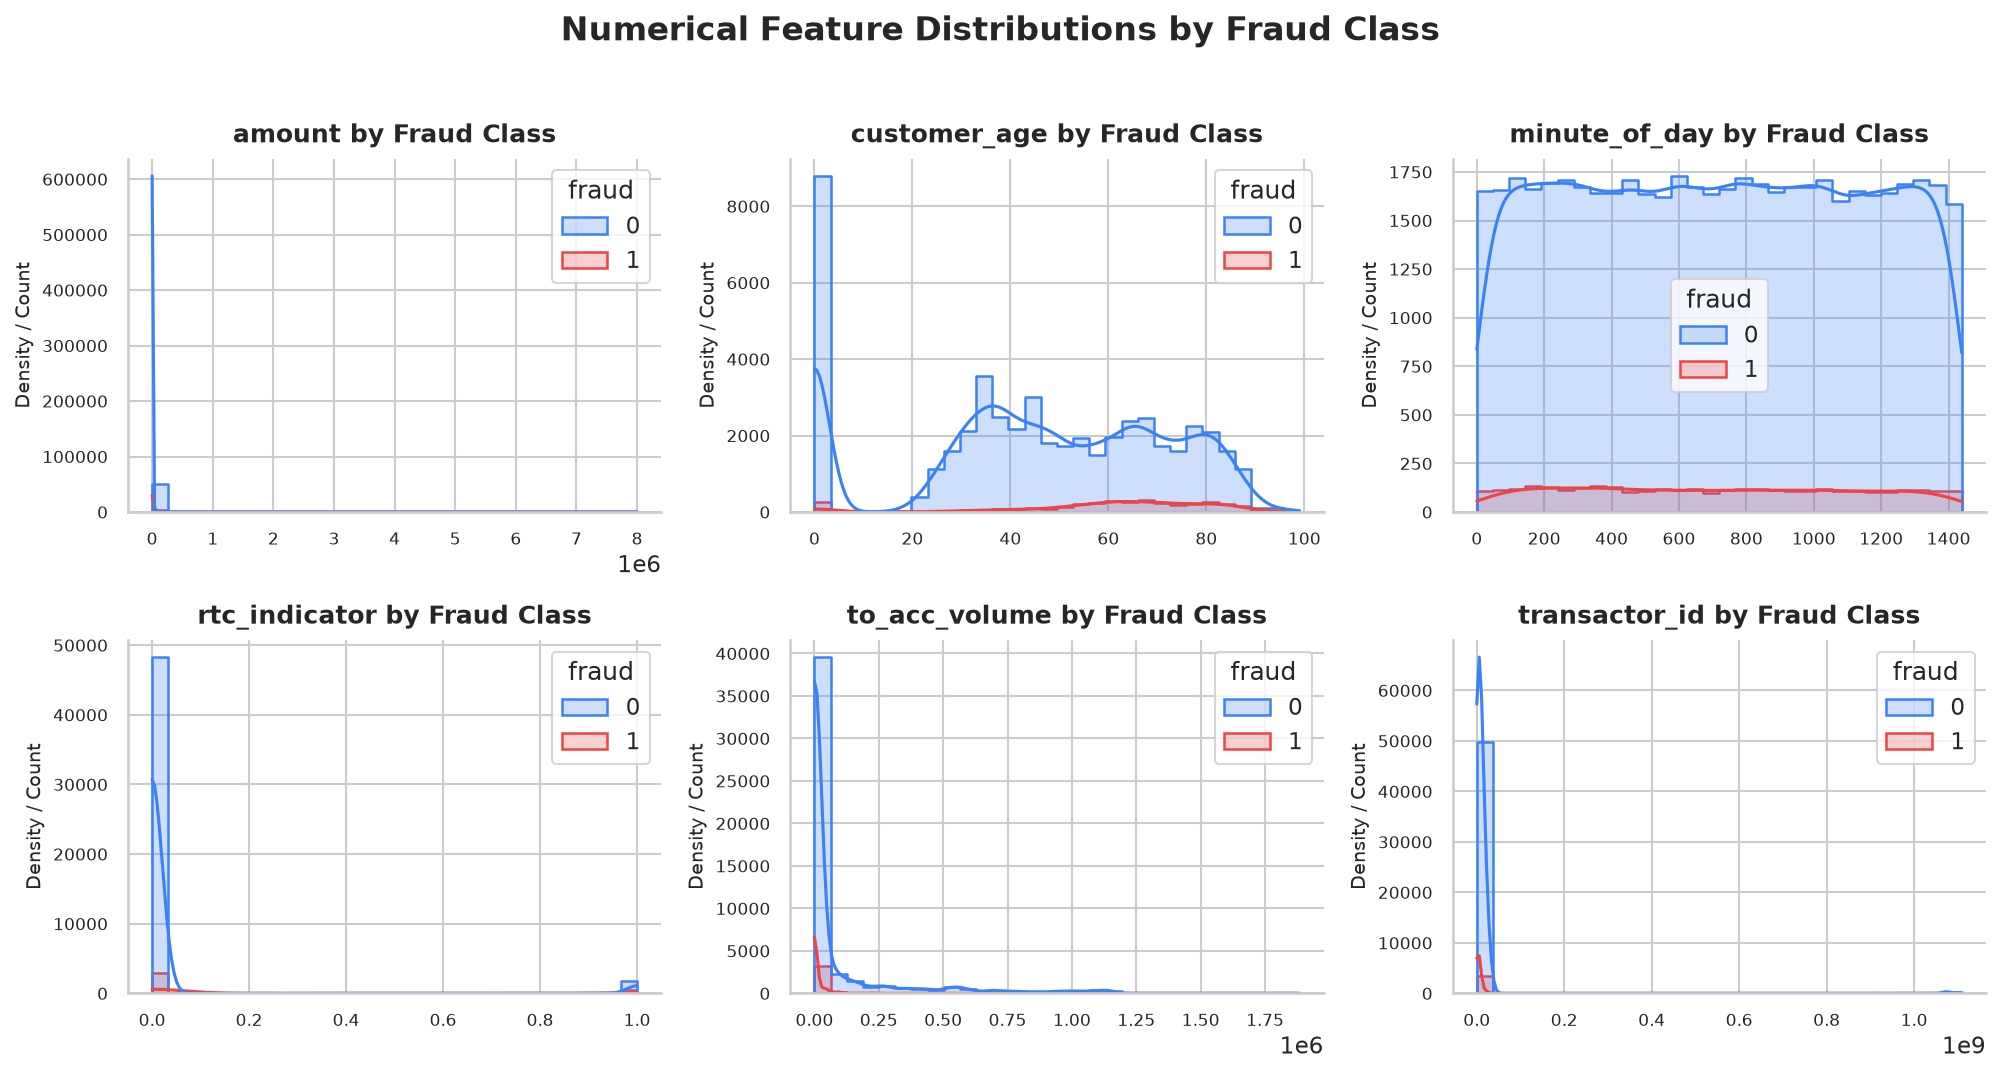

In [14]:
# Select numerical features, excluding target and single-value columns
num_cols = [
    c for c in fraud_data.select_dtypes(include=[np.number]).columns 
    if c != 'fraud' and fraud_data[c].nunique() > 1
]

# Define grid structure
n_cols = 3
n_vars = len(num_cols)
n_rows = math.ceil(n_vars / n_cols)

# Create figure and subplots
fig, axes = plt.subplots(
    nrows=n_rows, 
    ncols=n_cols, 
    figsize=(n_cols * 4.5, n_rows * 3.5)
)

# Flatten axes array for easy iteration
if n_vars == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Custom palette: Blue for Legitimate (0), Red for Fraud (1)
fraud_palette = {0: '#3B82F6', 1: '#EF4444'}

# PLOTTING LOOP
for i, col in enumerate(num_cols):
    ax = axes[i]
    
    # Check if both classes have enough unique points to calculate KDE curve safely
    can_fit_kde = True
    for val in fraud_data['fraud'].unique():
        subset = fraud_data[fraud_data['fraud'] == val][col].dropna()
        if len(subset) <= 1 or subset.nunique() <= 1:
            can_fit_kde = False
            break

    # Plot histogram with fraud class overlay
    sns.histplot(
        data=fraud_data,
        x=col,
        hue='fraud',
        kde=can_fit_kde,      # Dynamic KDE: turns off automatically if variance is 0
        ax=ax,
        palette=fraud_palette,
        element='step',        # Outlined steps
        common_norm=False,     # Normalizes each class independently
        bins=30,
        linewidth=1.2
    )
    
    # Style individual subplot
    ax.set_title(f'{col} by Fraud Class', fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel('')
    ax.set_ylabel('Density / Count', fontsize=9)
    ax.tick_params(axis='both', which='major', labelsize=8)
    
    # Despine
    sns.despine(ax=ax, top=True, right=True)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Final Layout Adjustments
fig.suptitle('Numerical Feature Distributions by Fraud Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### <b>2. Donut Charts for categorical variables

In [15]:
# -------------------------------------------------------------------
# 1. FILTER COLUMNS WITH < 5 UNIQUE VALUES
# -------------------------------------------------------------------
# Select categorical/discrete numerical features with 2-4 unique values
cat_cols = [
    col for col in fraud_data.columns 
    if col != 'fraud' and 1 < fraud_data[col].nunique() < 5
]

n_vars = len(cat_cols)
n_cols = 3
n_rows = math.ceil(n_vars / n_cols) if n_vars > 0 else 1

if n_vars == 0:
    print("No categorical columns found with fewer than 5 unique values.")
else:
    # -------------------------------------------------------------------
    # 2. CREATE SUBPLOT GRID
    # -------------------------------------------------------------------
    fig = make_subplots(
        rows=n_rows, 
        cols=n_cols,
        specs=[[{'type': 'domain'}] * n_cols for _ in range(n_rows)],
        subplot_titles=[f'<b>{col}</b>' for col in cat_cols]
    )

    # Color palette
    colors = ['#3B82F6', '#EF4444', '#10B981', '#F59E0B', '#8B5CF6']

    # -------------------------------------------------------------------
    # 3. PLOTTING LOOP WITH FRAUD BREAKDOWN
    # -------------------------------------------------------------------
    for i, col in enumerate(cat_cols):
        row = (i // n_cols) + 1
        col_idx = (i % n_cols) + 1
        
        # Group by category to calculate total volume AND fraud count/rate
        grouped = fraud_data.groupby(col)['fraud'].agg(
            Total_Count='count',
            Fraud_Count='sum',
            Fraud_Rate='mean'
        ).reset_index()
        
        grouped['Fraud_Pct_Str'] = (grouped['Fraud_Rate'] * 100).map('{:.1f}%'.format)

        # Build custom hover text including fraud details
        hover_text = [
            f"Category: {val}<br>"
            f"Total Transactions: {tot:,}<br>"
            f"Fraud Cases: {frd:,}<br>"
            f"<b>Fraud Rate: {pct}</b>"
            for val, tot, frd, pct in zip(
                grouped[col], 
                grouped['Total_Count'], 
                grouped['Fraud_Count'], 
                grouped['Fraud_Pct_Str']
            )
        ]

        # Add Donut Chart trace
        fig.add_trace(
            go.Pie(
                labels=grouped[col].astype(str),
                values=grouped['Total_Count'],
                hole=0.55,  # Donut hole size
                marker=dict(colors=colors, line=dict(color='#FFFFFF', width=2)),
                textinfo='label+percent',
                hoverinfo='text',
                hovertext=hover_text,
                showlegend=False
            ),
            row=row, 
            col=col_idx
        )

    # -------------------------------------------------------------------
    # 4. STYLING & LAYOUT ADJUSTMENTS
    # -------------------------------------------------------------------
    fig.update_layout(
        title_text="<b>Low-Cardinality Features (< 5 Categories) with Fraud Breakdown</b>",
        title_font=dict(size=16, family="Arial"),
        height=350 * n_rows,
        width=1000,
        template='plotly_white',
        margin=dict(t=80, b=40, l=40, r=40)
    )

    # Explicit renderer fall-back if notebook MIME type gives issues
    try:
        fig.show()
    except ValueError:
        fig.show(renderer="iframe")

### <b> 3. Inverted Bar Charts for categorical Variables with High Cardinality

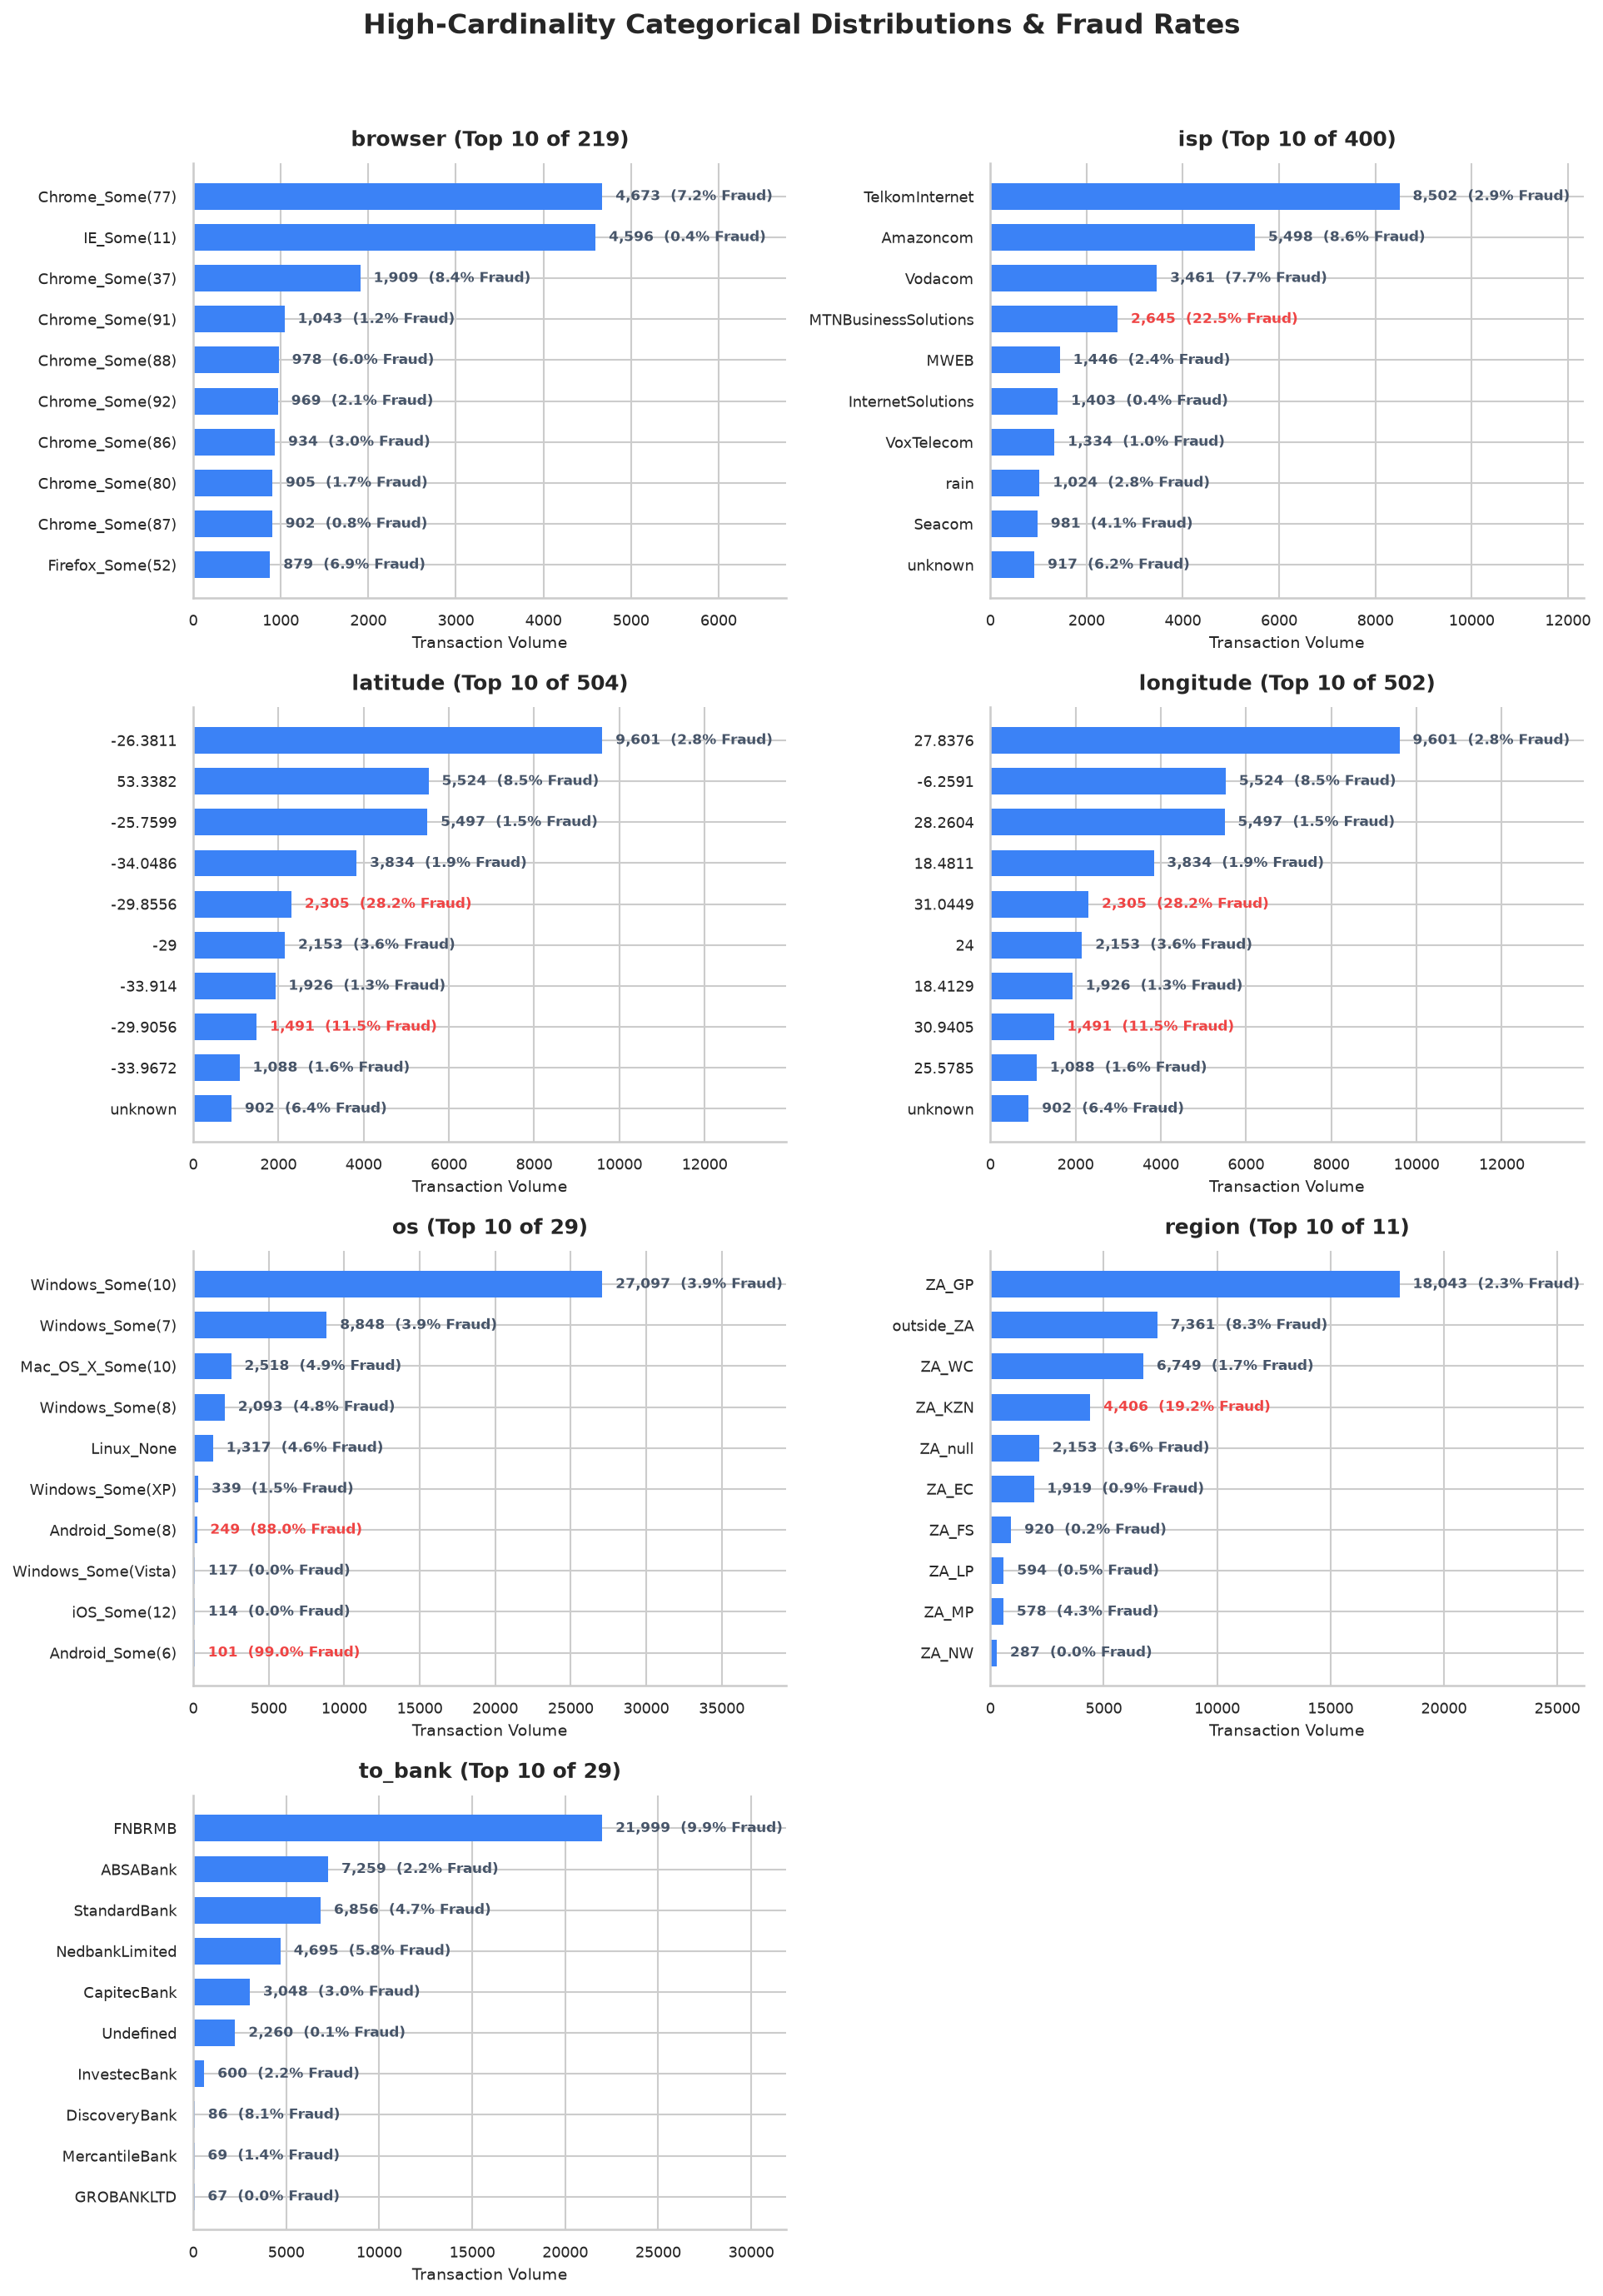

In [16]:
# Set clean modern theme
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 150

# -------------------------------------------------------------------
# 1. FILTER CATEGORICAL COLUMNS WITH nunique >= 5
# -------------------------------------------------------------------
# Find object/category columns (or discrete numeric categories) with >= 5 unique values
# Excluding target 'fraud' and high-cardinality unique IDs (e.g., transaction ID > 1000 unique)
cat_cols_high = [
    col for col in fraud_data.select_dtypes(include=['object', 'category', 'string']).columns 
    if col != 'fraud' and 5 <= fraud_data[col].nunique() <= 1000
]

# If non-numeric categorical data wasn't explicitly cast to 'object', check all non-fraud columns:
if len(cat_cols_high) == 0:
    cat_cols_high = [
        col for col in fraud_data.columns 
        if col != 'fraud' and 5 <= fraud_data[col].nunique() <= 50
    ]

n_vars = len(cat_cols_high)
TOP_N = 10  # Limit to top N categories per feature to maintain clean visuals

if n_vars == 0:
    print("No categorical columns found with 5 or more unique values.")
else:
    # Grid setup
    n_cols = 2  # 2 columns per row works best for horizontal bar charts
    n_rows = math.ceil(n_vars / n_cols)

    fig, axes = plt.subplots(
        nrows=n_rows, 
        ncols=n_cols, 
        figsize=(n_cols * 6.5, n_rows * 4.5)
    )

    # Flatten axes array for easy iteration
    if n_vars == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # -------------------------------------------------------------------
    # 2. PLOTTING LOOP
    # -------------------------------------------------------------------
    for i, col in enumerate(cat_cols_high):
        ax = axes[i]
        
        # Get top N most frequent categories for this column
        top_categories = fraud_data[col].value_counts().head(TOP_N).index
        subset = fraud_data[fraud_data[col].isin(top_categories)]
        
        # Calculate Volume Count and Fraud Rate per top category
        stats = subset.groupby(col).agg(
            Total=('fraud', 'count'),
            Fraud_Rate=('fraud', 'mean')
        ).reset_index()
        
        # Sort by total volume descending
        stats = stats.sort_values(by='Total', ascending=True) # Ascending for horizontal top-down look
        
        # Plot Horizontal Bars
        bars = ax.barh(
            y=stats[col].astype(str), 
            width=stats['Total'], 
            color='#3B82F6', 
            edgecolor='none', 
            height=0.65
        )
        
        # Annotate bars with Total Count and Fraud Rate %
        max_width = stats['Total'].max()
        for bar, f_rate in zip(bars, stats['Fraud_Rate']):
            width = bar.get_width()
            fraud_pct = f_rate * 100
            
            # Format annotation string
            label_text = f" {int(width):,}  ({fraud_pct:.1f}% Fraud)"
            
            # Color text red if fraud rate is above 10%
            text_color = '#EF4444' if fraud_pct >= 10 else '#475569'
            
            ax.text(
                x=width + (max_width * 0.02), 
                y=bar.get_y() + bar.get_height() / 2, 
                s=label_text, 
                va='center', 
                ha='left', 
                fontsize=8, 
                fontweight='bold',
                color=text_color
            )

        # Style individual subplot
        total_unique = fraud_data[col].nunique()
        title_suffix = f" (Top {TOP_N} of {total_unique})" if total_unique > TOP_N else ""
        ax.set_title(f'{col}{title_suffix}', fontsize=12, fontweight='bold', pad=10)
        ax.set_xlabel('Transaction Volume', fontsize=9)
        ax.set_ylabel('')
        ax.tick_params(axis='both', which='major', labelsize=8.5)
        ax.set_xlim(0, max_width * 1.45)  # Leave room on the right for text annotations
        
        # Despine border
        sns.despine(ax=ax, top=True, right=True)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # Final Layout Adjustments
    fig.suptitle('High-Cardinality Categorical Distributions & Fraud Rates', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

### <b> 4. Linking Transactor Identity with fraud


 TRANSACTOR IDENTITY SUMMARY STATISTICS
Total Transactions in Dataset : 53,420
Total Unique Transactor IDs  : 2,081
Avg Transactions per ID      : 25.67

--- TOP 10 MOST ACTIVE TRANSACTORS ---
 transactor_id  Total_Transactions  Fraud_Count  Fraud_Rate
      25199556                1227            3    0.002445
      19413705                 571            1    0.001751
       6138749                 406            2    0.004926
       2888269                 353            2    0.005666
      24075447                 352           10    0.028409
        231302                 257            1    0.003891
      23889536                 242            2    0.008264
       7560894                 218            1    0.004587
       1368802                 216           11    0.050926
       4145799                 197            2    0.010152

--- TOP 10 MOST FRAUDULENT TRANSACTORS ---
 transactor_id  Total_Transactions  Fraud_Count  Fraud_Rate
       4494459                  40         

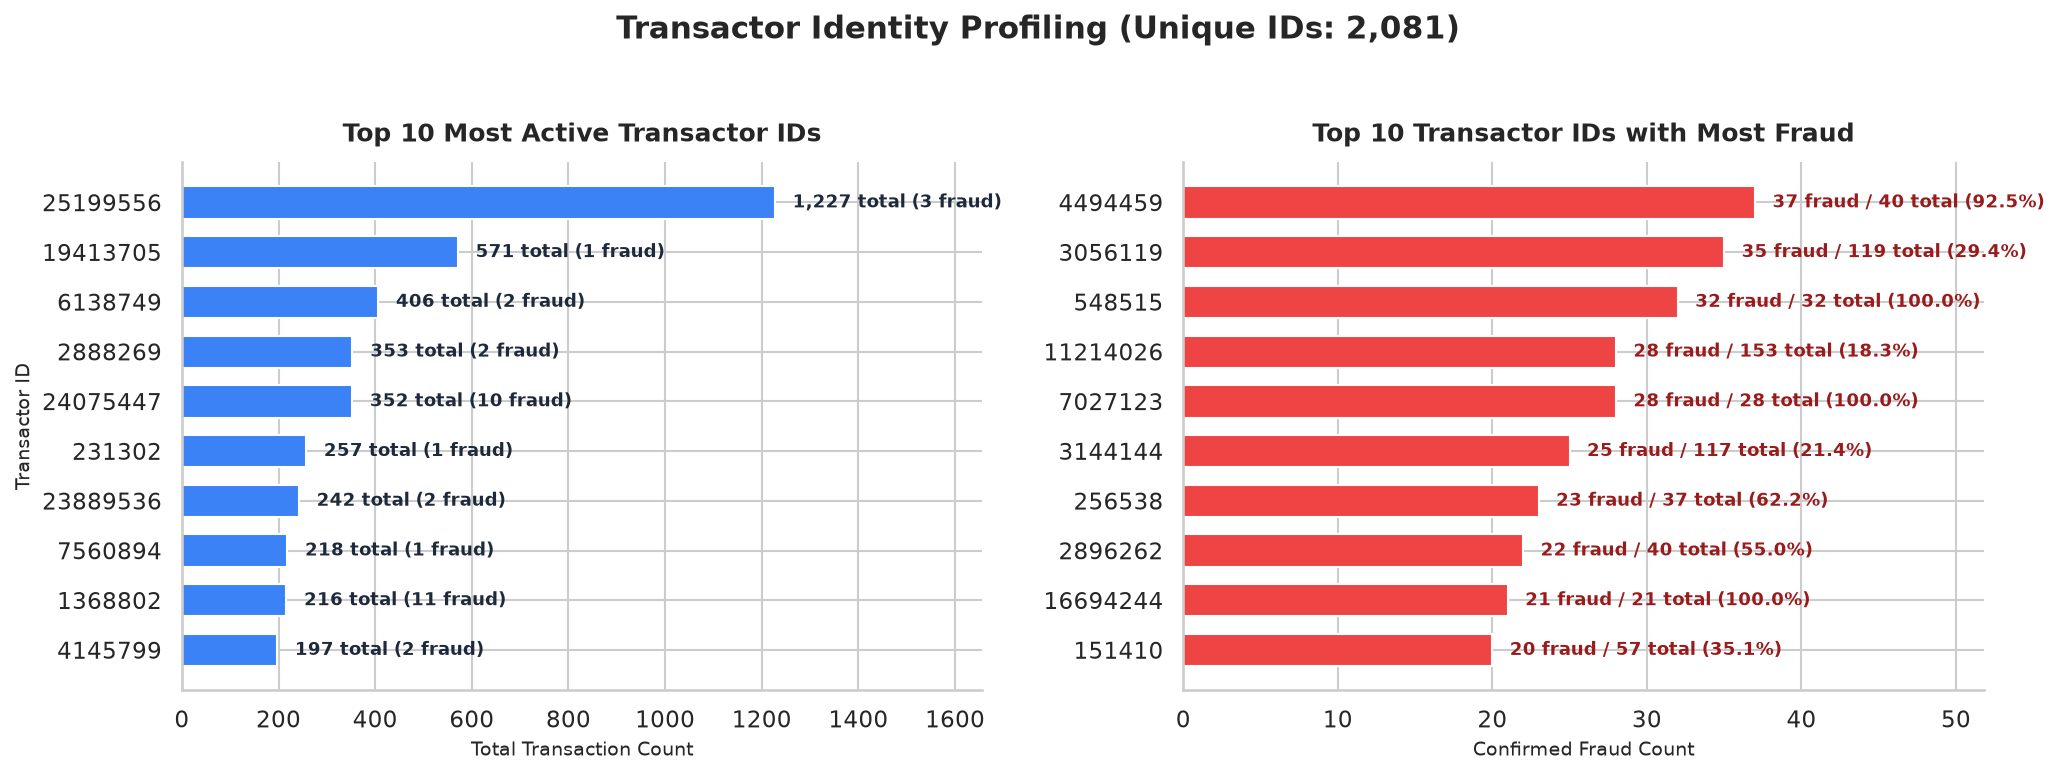

In [18]:
# Set clean visual style
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 150

# -------------------------------------------------------------------
# 1. SUMMARY STATISTICS: UNIQUE TRANSACTOR COUNT
# -------------------------------------------------------------------
total_unique = fraud_data['transactor_id'].nunique()
total_transactions = len(fraud_data)

print("=" * 55)
print(f" TRANSACTOR IDENTITY SUMMARY STATISTICS")
print("=" * 55)
print(f"Total Transactions in Dataset : {total_transactions:,}")
print(f"Total Unique Transactor IDs  : {total_unique:,}")
print(f"Avg Transactions per ID      : {total_transactions / total_unique:.2f}")
print("=" * 55)

# -------------------------------------------------------------------
# 2. TOP 10 MOST ACTIVE TRANSACTORS (By Total Volume)
# -------------------------------------------------------------------
top_10_active = fraud_data.groupby('transactor_id').agg(
    Total_Transactions=('fraud', 'count'),
    Fraud_Count=('fraud', 'sum'),
    Fraud_Rate=('fraud', 'mean')
).reset_index().sort_values(by='Total_Transactions', ascending=False).head(10)

print("\n--- TOP 10 MOST ACTIVE TRANSACTORS ---")
print(top_10_active.to_string(index=False))

# -------------------------------------------------------------------
# 3. TOP 10 TRANSACTORS WITH MOST FRAUDULENT TRANSACTIONS
# -------------------------------------------------------------------
top_10_fraudulent = fraud_data.groupby('transactor_id').agg(
    Total_Transactions=('fraud', 'count'),
    Fraud_Count=('fraud', 'sum'),
    Fraud_Rate=('fraud', 'mean')
).reset_index().sort_values(by=['Fraud_Count', 'Total_Transactions'], ascending=[False, False]).head(10)

print("\n--- TOP 10 MOST FRAUDULENT TRANSACTORS ---")
print(top_10_fraudulent.to_string(index=False))

# -------------------------------------------------------------------
# 4. VISUALIZATION MATRIX (Side-by-Side Horizontal Bar Charts)
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Top 10 Most Active Transactors
ax1 = axes[0]
bars1 = ax1.barh(
    y=top_10_active['transactor_id'].astype(str), 
    width=top_10_active['Total_Transactions'], 
    color='#3B82F6', 
    height=0.65
)

max_w1 = top_10_active['Total_Transactions'].max()
for bar, frd, rate in zip(bars1, top_10_active['Fraud_Count'], top_10_active['Fraud_Rate']):
    w = bar.get_width()
    ax1.text(
        x=w + (max_w1 * 0.02),
        y=bar.get_y() + bar.get_height() / 2,
        s=f" {int(w):,} total ({int(frd)} fraud)",
        va='center', fontsize=8.5, fontweight='bold', color='#1E293B'
    )

ax1.set_title('Top 10 Most Active Transactor IDs', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Total Transaction Count', fontsize=9)
ax1.set_ylabel('Transactor ID', fontsize=9)
ax1.set_xlim(0, max_w1 * 1.35)
ax1.invert_yaxis()  # Top-down ranking
sns.despine(ax=ax1, top=True, right=True)

# Plot 2: Top 10 Highest Fraud Counts
ax2 = axes[1]
bars2 = ax2.barh(
    y=top_10_fraudulent['transactor_id'].astype(str), 
    width=top_10_fraudulent['Fraud_Count'], 
    color='#EF4444', 
    height=0.65
)

max_w2 = top_10_fraudulent['Fraud_Count'].max()
for bar, tot, rate in zip(bars2, top_10_fraudulent['Total_Transactions'], top_10_fraudulent['Fraud_Rate']):
    w = bar.get_width()
    ax2.text(
        x=w + (max_w2 * 0.02),
        y=bar.get_y() + bar.get_height() / 2,
        s=f" {int(w):,} fraud / {int(tot):,} total ({rate*100:.1f}%)",
        va='center', fontsize=8.5, fontweight='bold', color='#991B1B'
    )

ax2.set_title('Top 10 Transactor IDs with Most Fraud', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Confirmed Fraud Count', fontsize=9)
ax2.set_ylabel('')
ax2.set_xlim(0, max_w2 * 1.4)
ax2.invert_yaxis()  # Top-down ranking
sns.despine(ax=ax2, top=True, right=True)

plt.suptitle(f'Transactor Identity Profiling (Unique IDs: {total_unique:,})', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### 5. Correlation Analysis

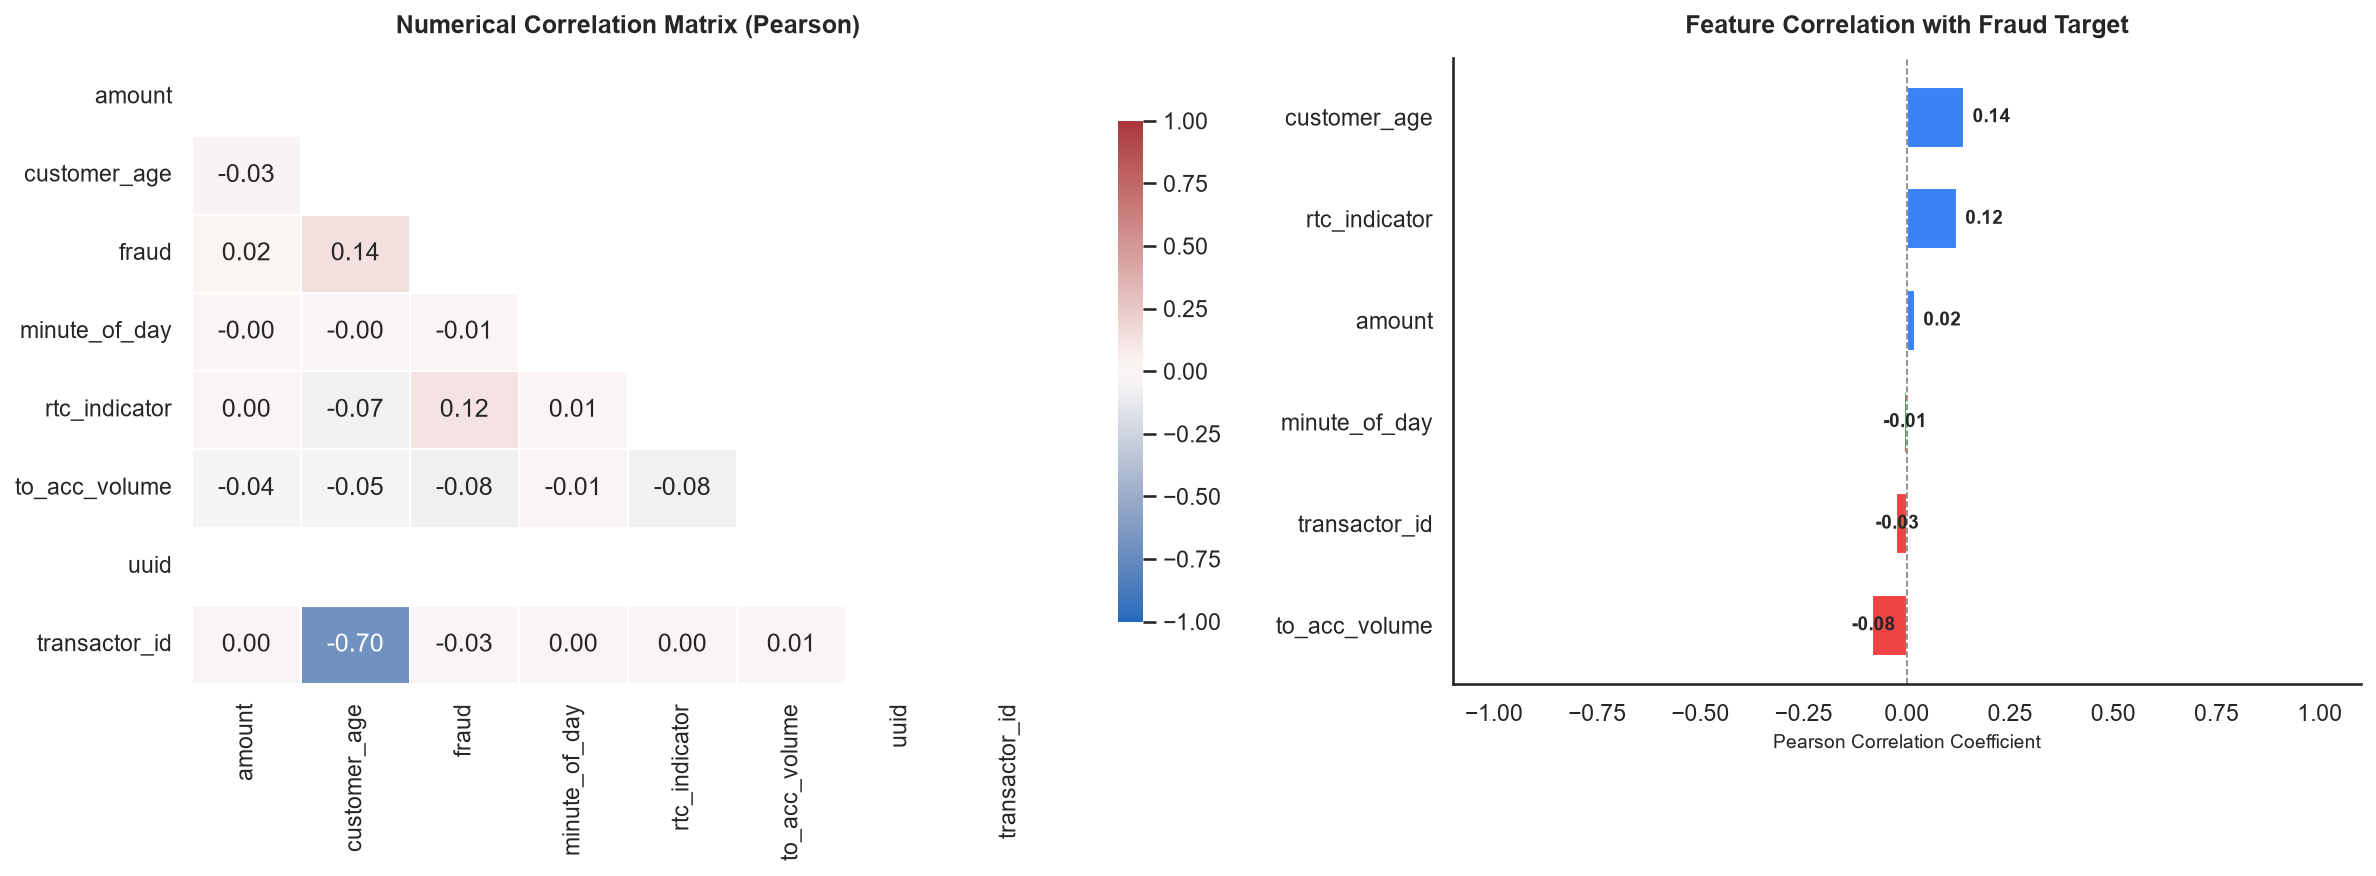

In [19]:
# Set clean visual theme
sns.set_theme(style="white")
plt.rcParams['figure.dpi'] = 150

# -------------------------------------------------------------------
# 1. SELECT NUMERICAL COLUMNS
# -------------------------------------------------------------------
num_cols = fraud_data.select_dtypes(include=[np.number]).columns.tolist()

# Compute Pearson Correlation Matrix
corr_matrix = fraud_data[num_cols].corr()

# -------------------------------------------------------------------
# 2. PLOT 1: PAIRWISE HEATMAP
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1.2, 1]})

# Mask the upper triangle for a clean, non-redundant visual
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap='vlag', 
    vmin=-1, 
    vmax=1, 
    center=0,
    linewidths=0.8, 
    cbar_kws={"shrink": 0.8},
    ax=axes[0]
)
axes[0].set_title('Numerical Correlation Matrix (Pearson)', fontsize=12, fontweight='bold', pad=12)

# -------------------------------------------------------------------
# 3. PLOT 2: RANKED CORRELATION WITH TARGET ('fraud')
# -------------------------------------------------------------------
if 'fraud' in corr_matrix.columns:
    fraud_corr = corr_matrix['fraud'].drop('fraud').sort_values(ascending=True)
    
    colors = ['#EF4444' if x < 0 else '#3B82F6' for x in fraud_corr.values]
    
    bars = axes[1].barh(y=fraud_corr.index, width=fraud_corr.values, color=colors, height=0.6)
    
    # Annotate bar values
    for bar in bars:
        w = bar.get_width()
        offset = 0.02 if w >= 0 else -0.05
        axes[1].text(
            x=w + offset, 
            y=bar.get_y() + bar.get_height() / 2, 
            s=f"{w:.2f}", 
            va='center', 
            fontsize=9, 
            fontweight='bold'
        )

    axes[1].axvline(0, color='gray', linestyle='--', linewidth=0.8)
    axes[1].set_title('Feature Correlation with Fraud Target', fontsize=12, fontweight='bold', pad=12)
    axes[1].set_xlabel('Pearson Correlation Coefficient', fontsize=9)
    axes[1].set_xlim(-1.1, 1.1)
    sns.despine(ax=axes[1], top=True, right=True)

plt.tight_layout()
plt.show()

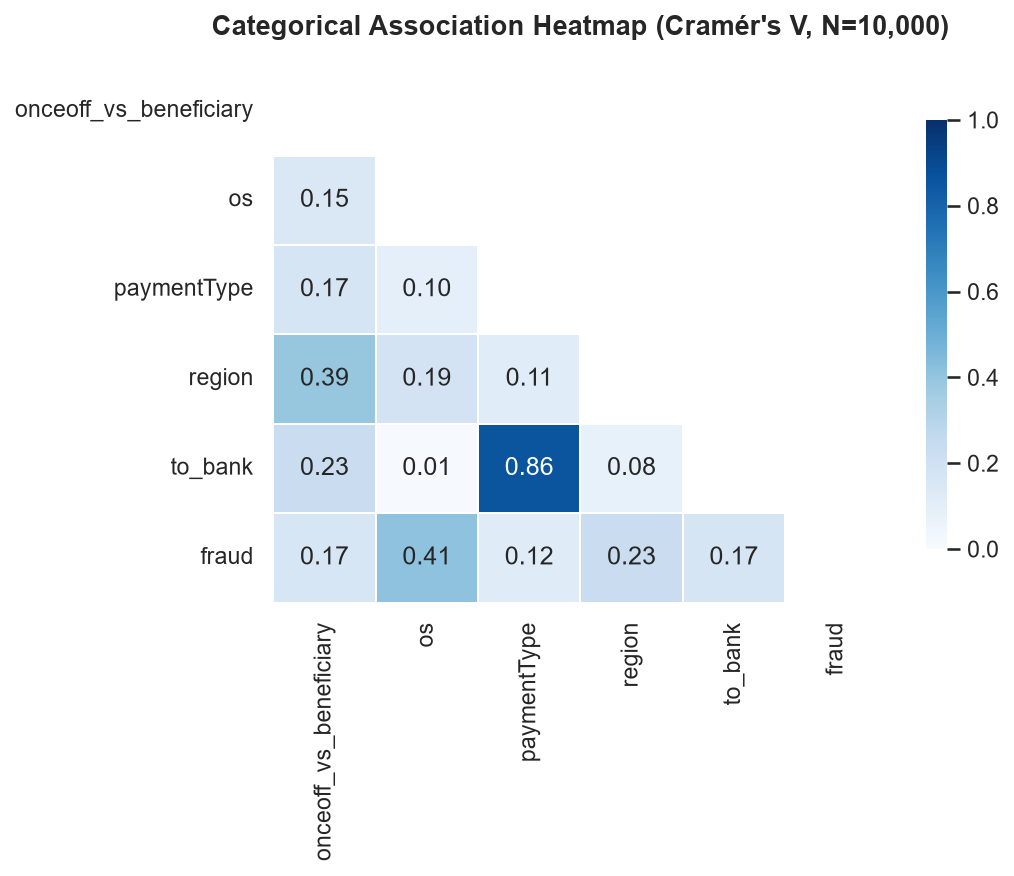

In [22]:
# Set clean visual style
sns.set_theme(style="white")
plt.rcParams['figure.dpi'] = 150

# -------------------------------------------------------------------
# 1. MEMORY-SAFE CATEGORICAL SELECTION (< 100 UNIQUE VALUES)
# -------------------------------------------------------------------
# Exclude high-cardinality IDs (like transactor_id) that cause MemoryError
MAX_CARDINALITY = 100

cat_cols = [
    col for col in fraud_data.select_dtypes(include=['object', 'category', 'string']).columns 
    if col != 'fraud' and 1 < fraud_data[col].nunique() < MAX_CARDINALITY
]

# Include 'fraud' as a discrete target category
if 'fraud' in fraud_data.columns and 'fraud' not in cat_cols:
    cat_cols.append('fraud')

# If no 'object' dtype columns matched, check numeric categorical flags
if len(cat_cols) <= 1:
    cat_cols = [
        col for col in fraud_data.columns 
        if 1 < fraud_data[col].nunique() < MAX_CARDINALITY
    ]

# -------------------------------------------------------------------
# 2. CRAMÉR'S V FUNCTION WITH SAMPLE SAFETY
# -------------------------------------------------------------------
def cramers_v_safe(x, y):
    """Calculates Cramér's V safely using pd.crosstab."""
    confusion_matrix = pd.crosstab(x, y)
    
    # Avoid calculating if contingency matrix is empty or too large
    if confusion_matrix.size == 0 or confusion_matrix.shape[0] < 2 or confusion_matrix.shape[1] < 2:
        return 0.0
        
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    if n == 0:
        return 0.0
        
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    
    # Bias correction
    phi2corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    rcorr = r - ((r-1)**2) / (n-1)
    kcorr = k - ((k-1)**2) / (n-1)
    
    if min((kcorr-1), (rcorr-1)) <= 0:
        return 0.0
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# -------------------------------------------------------------------
# 3. COMPUTE MATRIX ON SAMPLED DATA
# -------------------------------------------------------------------
# Take a random sample of 10,000 rows to further optimize RAM
sample_size = min(10000, len(fraud_data))
sample_df = fraud_data[cat_cols].sample(n=sample_size, random_state=42)

cramer_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

for c1 in cat_cols:
    for c2 in cat_cols:
        if c1 == c2:
            cramer_matrix.loc[c1, c2] = 1.0
        else:
            cramer_matrix.loc[c1, c2] = cramers_v_safe(sample_df[c1], sample_df[c2])

# -------------------------------------------------------------------
# 4. PLOT CATEGORICAL ASSOCIATION HEATMAP
# -------------------------------------------------------------------
if len(cat_cols) > 1:
    plt.figure(figsize=(min(10, len(cat_cols)*1.2), min(8, len(cat_cols)*1.0)))
    
    # Mask upper triangle for a clean look
    mask = np.triu(np.ones_like(cramer_matrix, dtype=bool))
    
    sns.heatmap(
        cramer_matrix, 
        mask=mask,
        annot=True, 
        fmt=".2f", 
        cmap='Blues', 
        vmin=0, 
        vmax=1, 
        linewidths=0.8,
        cbar_kws={"shrink": .8}
    )
    plt.title(f"Categorical Association Heatmap (Cramér's V, N={sample_size:,})", fontsize=13, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough low-cardinality categorical variables found to plot a heatmap.")

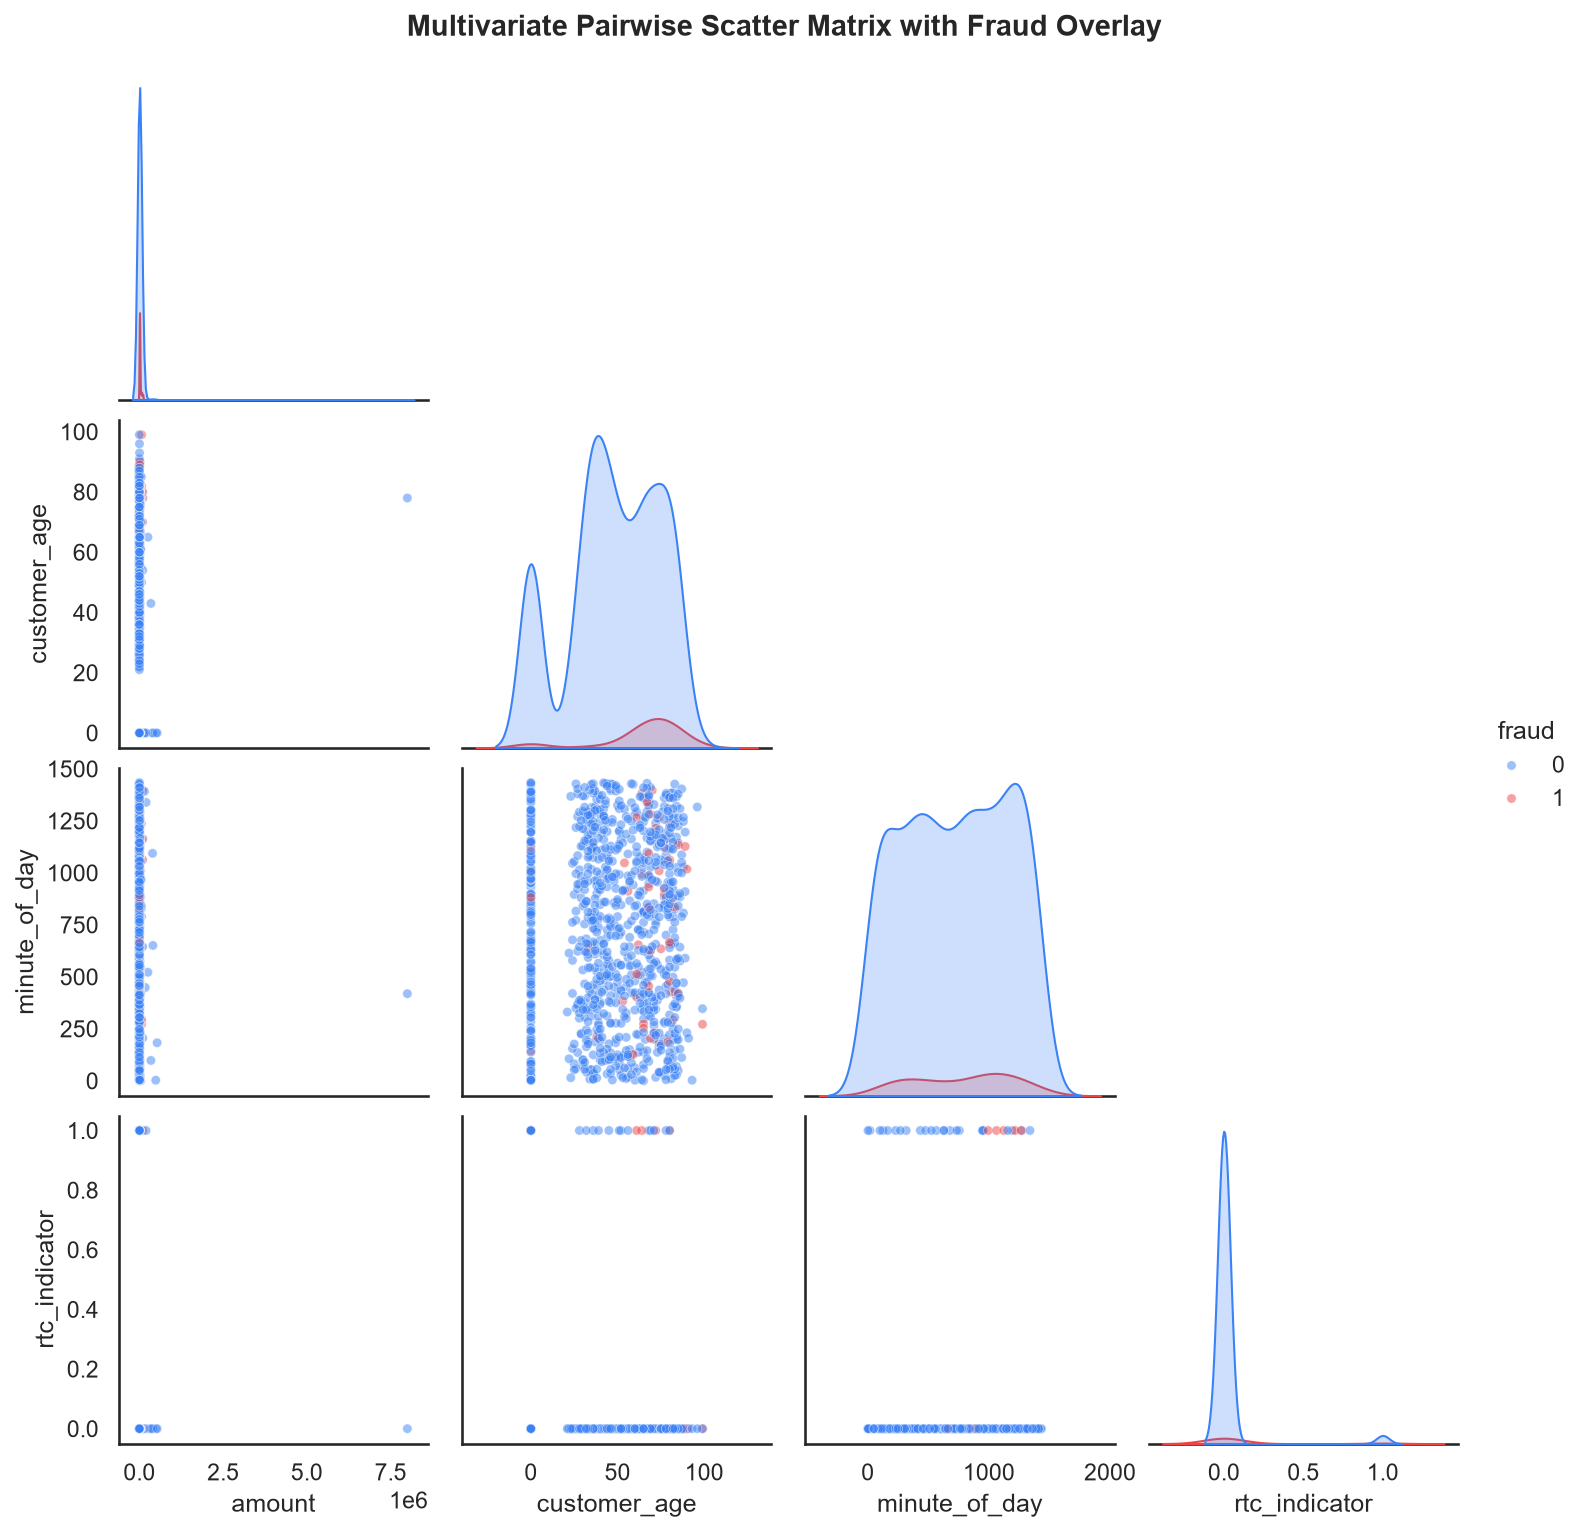

In [23]:
# Sample 1,000 rows to keep computation fast and plot readable
sample_df = fraud_data.sample(n=min(1000, len(fraud_data)), random_state=42)

# Pick top 4 numerical features + target
top_num_features = num_cols[:4] if 'fraud' not in num_cols[:4] else num_cols[:5]
if 'fraud' not in top_num_features:
    top_num_features.append('fraud')

g = sns.pairplot(
    data=sample_df[top_num_features],
    hue='fraud',
    palette={0: '#3B82F6', 1: '#EF4444'},
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 20},
    corner=True  # Renders lower triangle only
)
g.fig.suptitle('Multivariate Pairwise Scatter Matrix with Fraud Overlay', fontsize=14, fontweight='bold', y=1.02)
plt.show()

In [25]:

# Sample for smooth browser performance
plotly_sample = fraud_data.sample(n=min(500, len(fraud_data)), random_state=42)

# Select 4-6 continuous variables + target
select_cols = [c for c in num_cols if c != 'fraud'][:5] + ['fraud']

fig = px.parallel_coordinates(
    plotly_sample[select_cols],
    color="fraud",
    color_continuous_scale=[(0, '#3B82F6'), (1, '#EF4444')],
    title="<b>Multivariate Trajectory Analysis (Parallel Coordinates)</b>"
)

fig.update_layout(template='plotly_white')

try:
    fig.show()
except ValueError:
    fig.show(renderer="iframe")

### <b> 6. Examining missing data

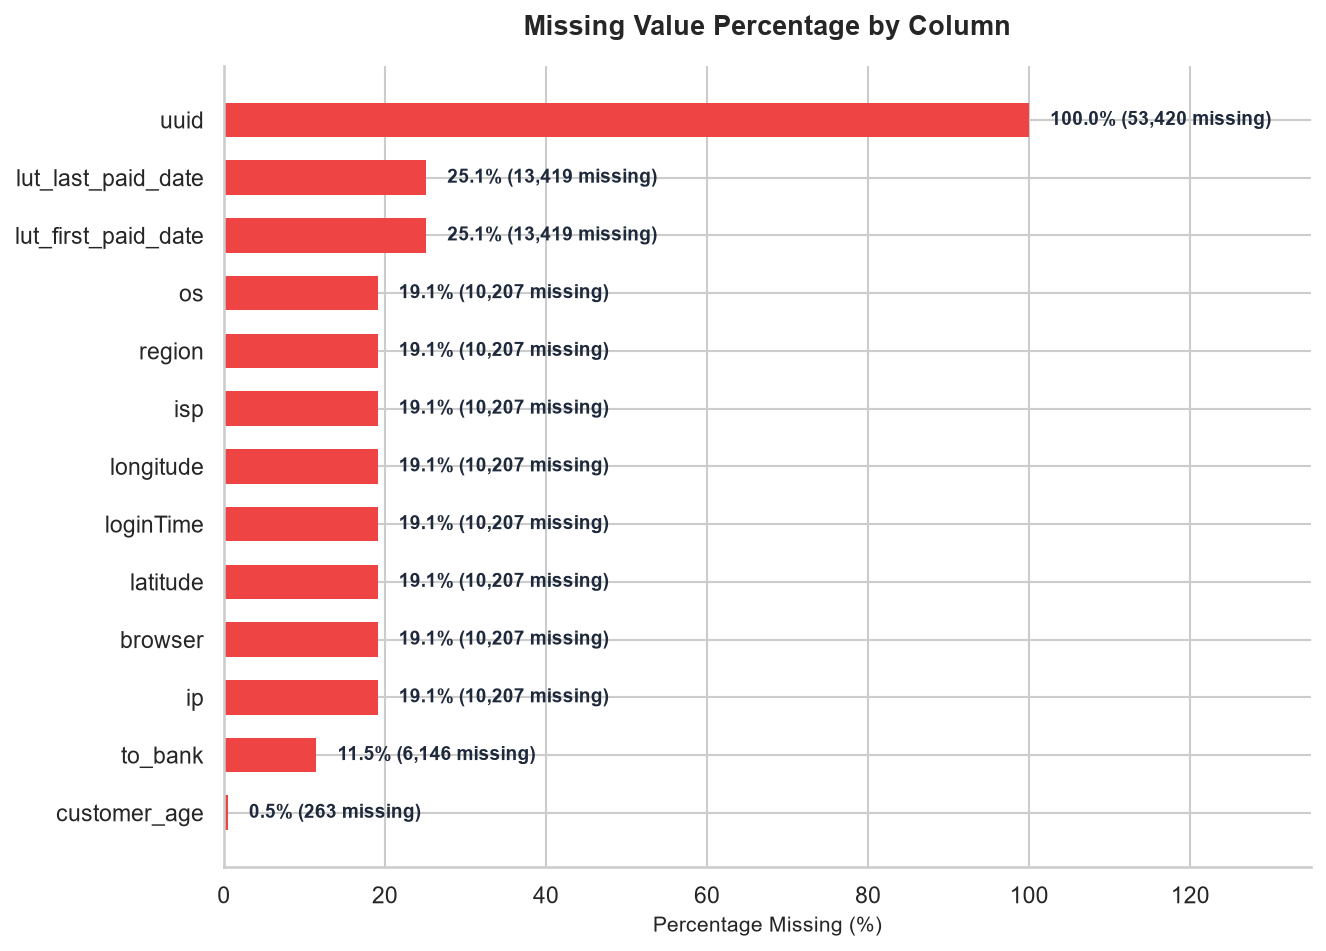

In [26]:
# Set theme
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 150

# -------------------------------------------------------------------
# 1. CALCULATE MISSING VALUE SUMMARY
# -------------------------------------------------------------------
null_counts = fraud_data.isnull().sum()
null_pct = (fraud_data.isnull().sum() / len(fraud_data)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': null_counts,
    'Missing_Percentage': null_pct
}).query('Missing_Count > 0').sort_values(by='Missing_Count', ascending=True)

if missing_df.empty:
    print(" Great news! There are zero missing values in this dataset.")
else:
    # -------------------------------------------------------------------
    # 2. PLOT MISSING VALUE PERCENTAGE BAR CHART
    # -------------------------------------------------------------------
    plt.figure(figsize=(9, max(4, len(missing_df) * 0.5)))
    
    bars = plt.barh(
        y=missing_df.index, 
        width=missing_df['Missing_Percentage'], 
        color='#EF4444',  # Soft red to signal missingness
        edgecolor='none', 
        height=0.6
    )
    
    # Annotate bars with Percentage and Raw Count
    max_w = missing_df['Missing_Percentage'].max()
    for bar, count in zip(bars, missing_df['Missing_Count']):
        w = bar.get_width()
        plt.text(
            x=w + (max_w * 0.02),
            y=bar.get_y() + bar.get_height() / 2,
            s=f" {w:.1f}% ({count:,} missing)",
            va='center',
            fontsize=9,
            fontweight='bold',
            color='#1E293B'
        )

    plt.title('Missing Value Percentage by Column', fontsize=13, fontweight='bold', pad=15)
    plt.xlabel('Percentage Missing (%)', fontsize=10)
    plt.ylabel('')
    plt.xlim(0, max_w * 1.35)
    sns.despine(top=True, right=True)
    plt.tight_layout()
    plt.show()

<Figure size 1500x750 with 0 Axes>

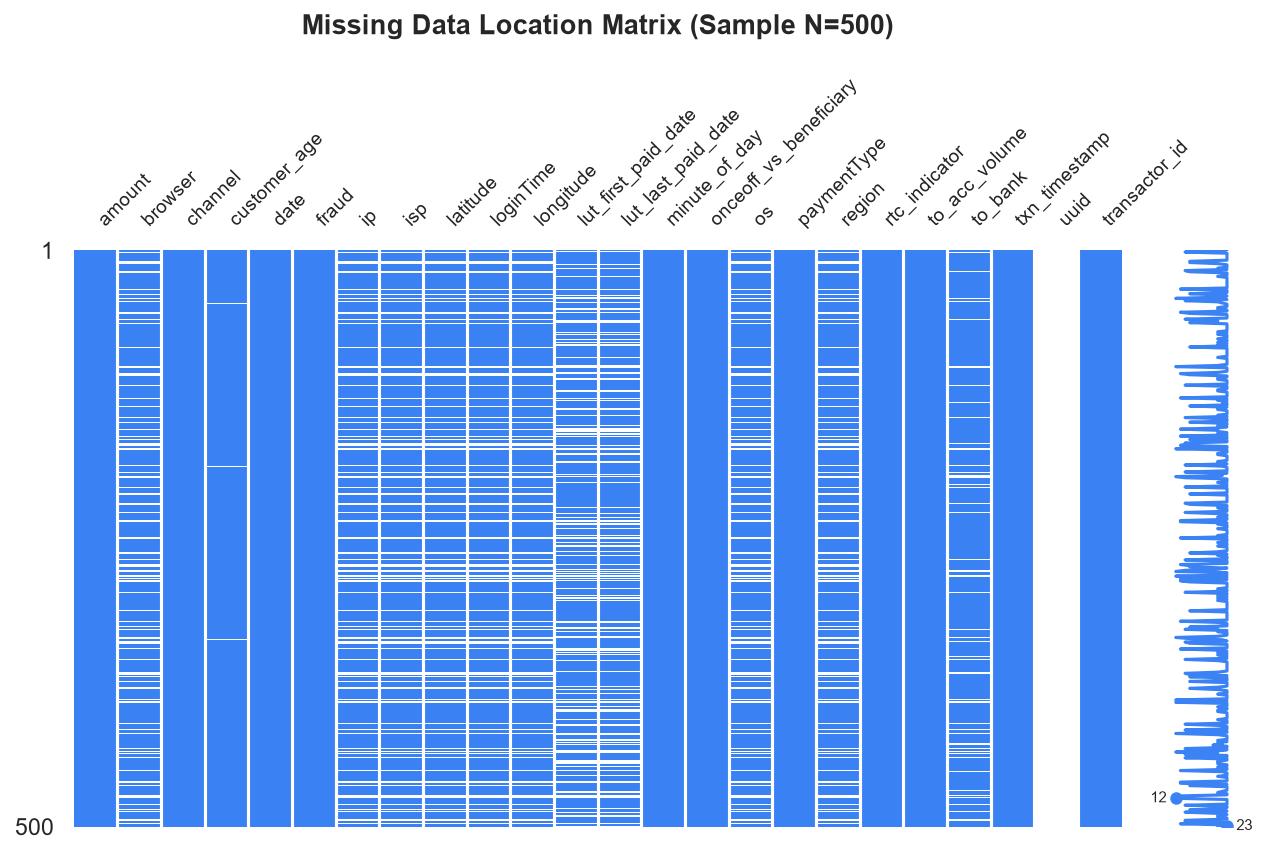

In [27]:
# Sample 500 rows for high visual clarity in the matrix
sample_size = min(500, len(fraud_data))
sample_df = fraud_data.sample(n=sample_size, random_state=42)

plt.figure(figsize=(10, 5))
msno.matrix(
    sample_df, 
    sparkline=True, 
    figsize=(10, 5), 
    fontsize=9, 
    color=(0.23, 0.51, 0.96) # Electric blue for present data
)
plt.title(f'Missing Data Location Matrix (Sample N={sample_size:,})', fontsize=13, fontweight='bold', pad=20)
plt.show()

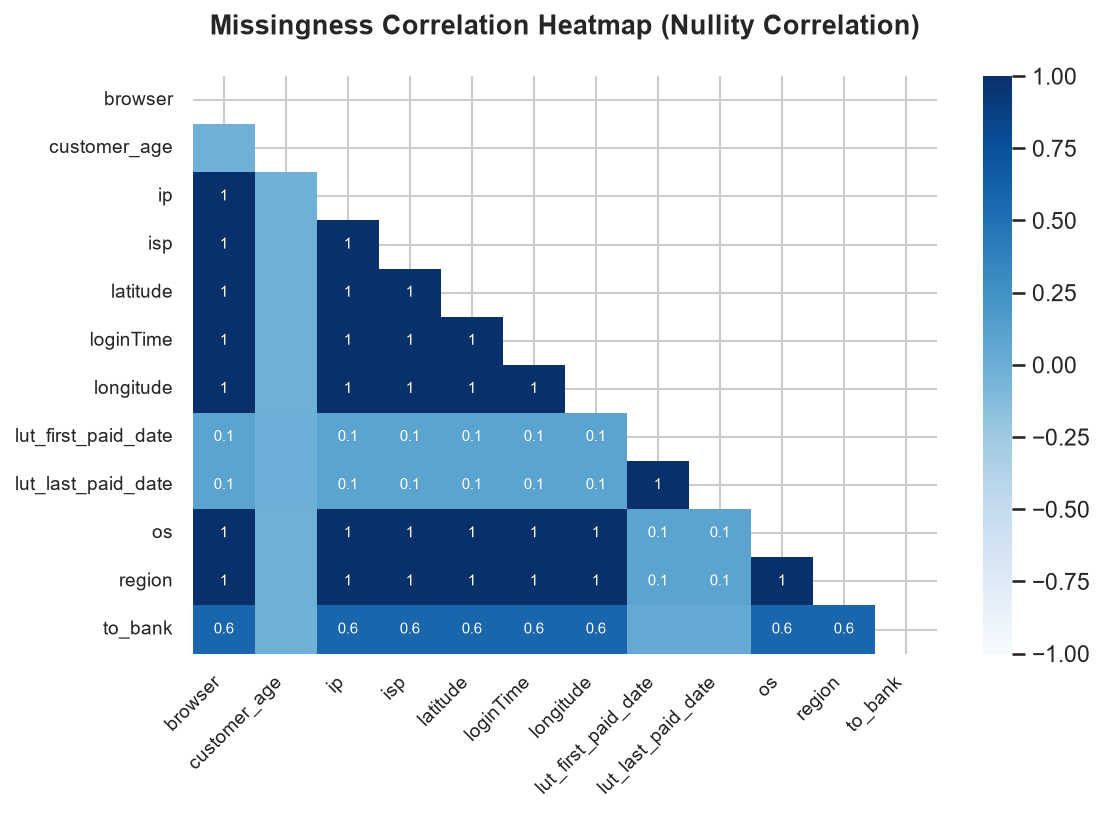

In [28]:
# Generate Nullity Correlation Heatmap
# Note: Only displays columns that actually contain missing values
if fraud_data.isnull().sum().sum() > 0:
    msno.heatmap(
        fraud_data, 
        figsize=(8, 5), 
        fontsize=9, 
        cmap='Blues'
    )
    plt.title('Missingness Correlation Heatmap (Nullity Correlation)', fontsize=13, fontweight='bold', pad=20)
    plt.show()
else:
    print("No missing values present to calculate nullity correlation.")

### <b>7. Cumulative Fraud Gain / Lift Chart

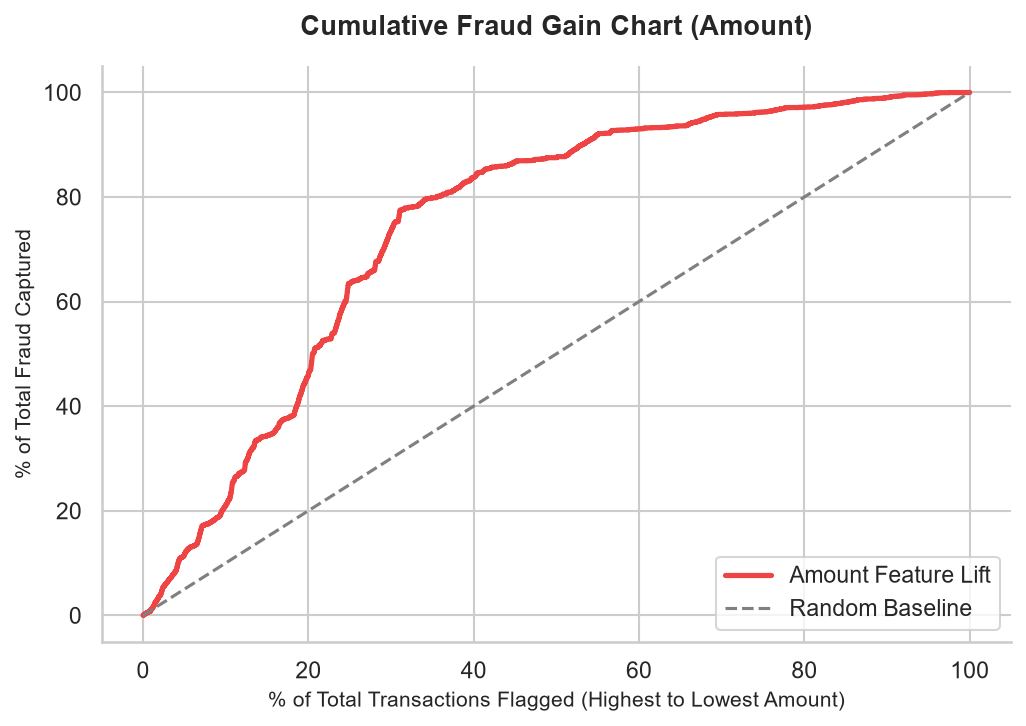

In [29]:
# Sort dataset by a key feature (e.g., 'amount') descending
df_sorted = fraud_data.sort_values(by='amount', ascending=False).reset_index(drop=True)

# Compute cumulative percentage of total volume vs cumulative percentage of fraud captured
df_sorted['cum_fraud'] = df_sorted['fraud'].cumsum() / df_sorted['fraud'].sum()
df_sorted['cum_pop'] = (df_sorted.index + 1) / len(df_sorted)

plt.figure(figsize=(7, 5))
plt.plot(df_sorted['cum_pop'] * 100, df_sorted['cum_fraud'] * 100, color='#EF4444', linewidth=2.5, label='Amount Feature Lift')
plt.plot([0, 100], [0, 100], color='gray', linestyle='--', label='Random Baseline')

plt.title('Cumulative Fraud Gain Chart (Amount)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('% of Total Transactions Flagged (Highest to Lowest Amount)', fontsize=10)
plt.ylabel('% of Total Fraud Captured', fontsize=10)
plt.legend(loc='lower right')
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

### <b> 8. Time-Series Volatility / Velocity Spikes

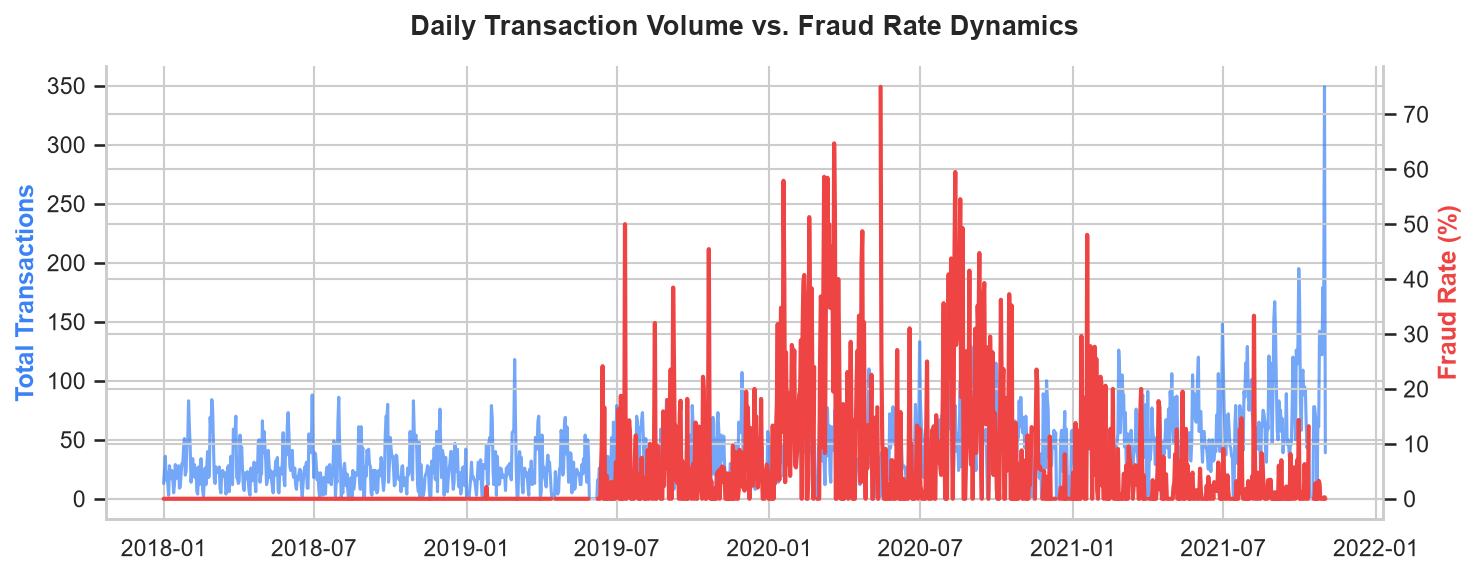

In [33]:
# Assuming a date/time column exists
if 'date' in fraud_data.columns:
    fraud_data['date'] = pd.to_datetime(fraud_data['date'])
    time_series = fraud_data.resample('D', on='date')['fraud'].agg(['count', 'sum', 'mean']).reset_index()

    fig, ax1 = plt.subplots(figsize=(10, 4))

    ax1.plot(time_series['date'], time_series['count'], color='#3B82F6', label='Total Volume', alpha=0.7)
    ax1.set_ylabel('Total Transactions', color='#3B82F6', fontweight='bold')
    
    ax2 = ax1.twinx()
    ax2.plot(time_series['date'], time_series['mean'] * 100, color='#EF4444', label='Fraud Rate %', linewidth=2)
    ax2.set_ylabel('Fraud Rate (%)', color='#EF4444', fontweight='bold')

    plt.title('Daily Transaction Volume vs. Fraud Rate Dynamics', fontsize=13, fontweight='bold', pad=15)
    sns.despine(top=True, right=False)
    plt.tight_layout()
    plt.show()

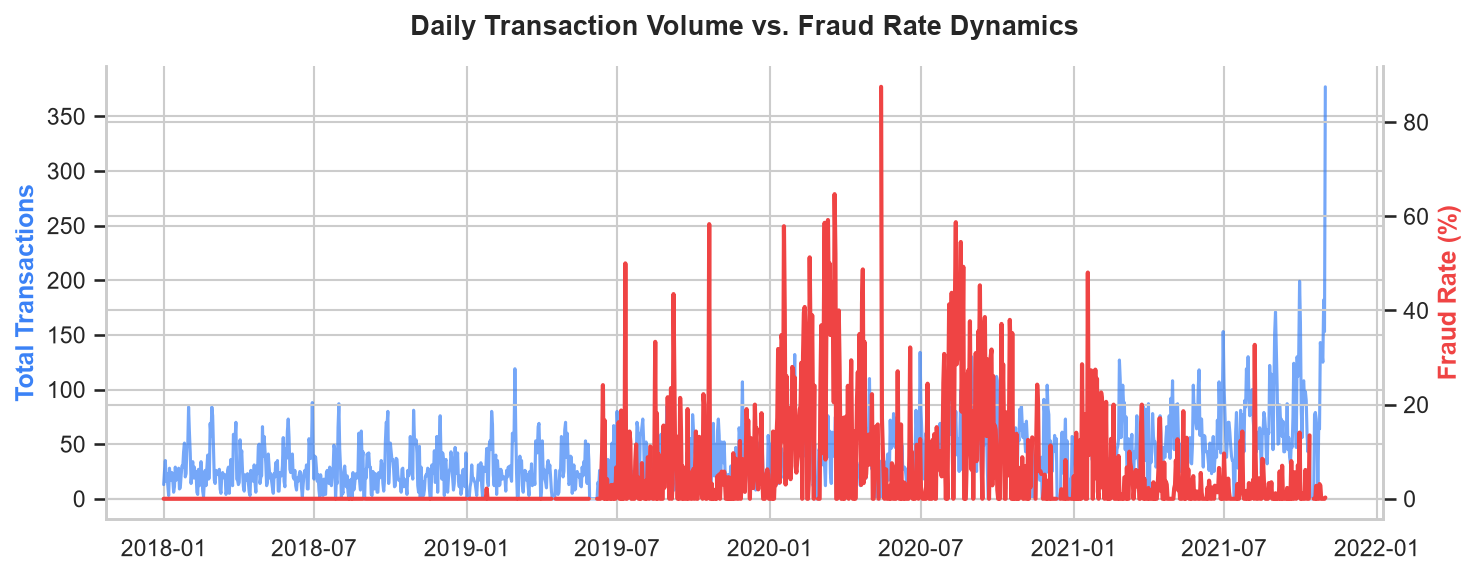

In [43]:
# Assuming a txn_timestamp/time column exists
if 'txn_timestamp' in fraud_data.columns:
    fraud_data['txn_timestamp'] = pd.to_datetime(fraud_data['txn_timestamp'])
    time_series = fraud_data.resample('D', on='txn_timestamp')['fraud'].agg(['count', 'sum', 'mean']).reset_index()

    fig, ax1 = plt.subplots(figsize=(10, 4))

    ax1.plot(time_series['txn_timestamp'], time_series['count'], color='#3B82F6', label='Total Volume', alpha=0.7)
    ax1.set_ylabel('Total Transactions', color='#3B82F6', fontweight='bold')
    
    ax2 = ax1.twinx()
    ax2.plot(time_series['txn_timestamp'], time_series['mean'] * 100, color='#EF4444', label='Fraud Rate %', linewidth=2)
    ax2.set_ylabel('Fraud Rate (%)', color='#EF4444', fontweight='bold')

    plt.title('Daily Transaction Volume vs. Fraud Rate Dynamics', fontsize=13, fontweight='bold', pad=15)
    sns.despine(top=True, right=False)
    plt.tight_layout()
    plt.show()

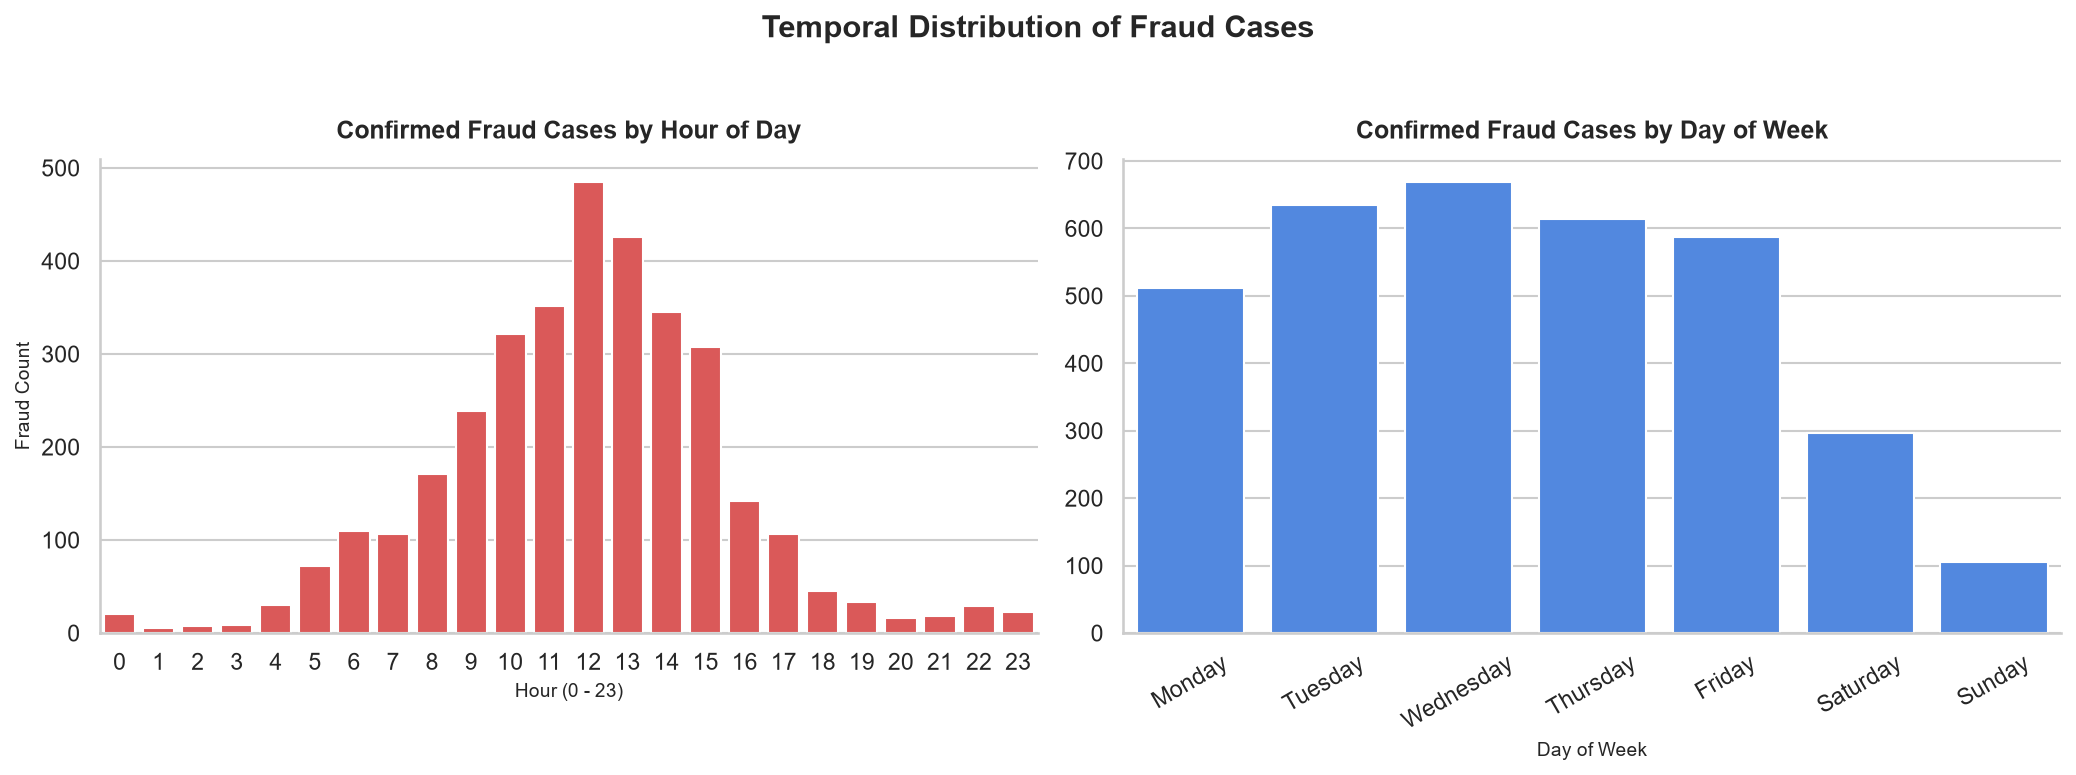

 Peak Fraud Hour : 12:00 - 12:59 (485 cases)
 Peak Fraud Day  : Wednesday (669 cases)


In [44]:
# Ensure timestamp is parsed correctly
fraud_data['txn_datetime'] = pd.to_datetime(fraud_data['txn_timestamp'], errors='coerce')

# Extract temporal components
fraud_data['hour'] = fraud_data['txn_datetime'].dt.hour
fraud_data['day_of_week'] = fraud_data['txn_datetime'].dt.day_name()

# -------------------------------------------------------------------
# VISUALIZATION: FRAUD BY HOUR OF DAY & DAY OF WEEK
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Fraud Count by Hour of Day
hourly_fraud = fraud_data[fraud_data['fraud'] == 1]['hour'].value_counts().sort_index()
sns.barplot(x=hourly_fraud.index, y=hourly_fraud.values, color='#EF4444', ax=axes[0])
axes[0].set_title('Confirmed Fraud Cases by Hour of Day', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Hour (0 - 23)', fontsize=9)
axes[0].set_ylabel('Fraud Count', fontsize=9)
sns.despine(ax=axes[0], top=True, right=True)

# Plot 2: Fraud Count by Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_fraud = fraud_data[fraud_data['fraud'] == 1]['day_of_week'].value_counts().reindex(day_order)
sns.barplot(x=daily_fraud.index, y=daily_fraud.values, color='#3B82F6', ax=axes[1])
axes[1].set_title('Confirmed Fraud Cases by Day of Week', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Day of Week', fontsize=9)
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=30)
sns.despine(ax=axes[1], top=True, right=True)

plt.suptitle('Temporal Distribution of Fraud Cases', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# Print exact top period
top_hour = hourly_fraud.idxmax()
top_day = daily_fraud.idxmax()
print(f" Peak Fraud Hour : {top_hour}:00 - {top_hour}:59 ({hourly_fraud.max():,} cases)")
print(f" Peak Fraud Day  : {top_day} ({daily_fraud.max():,} cases)")

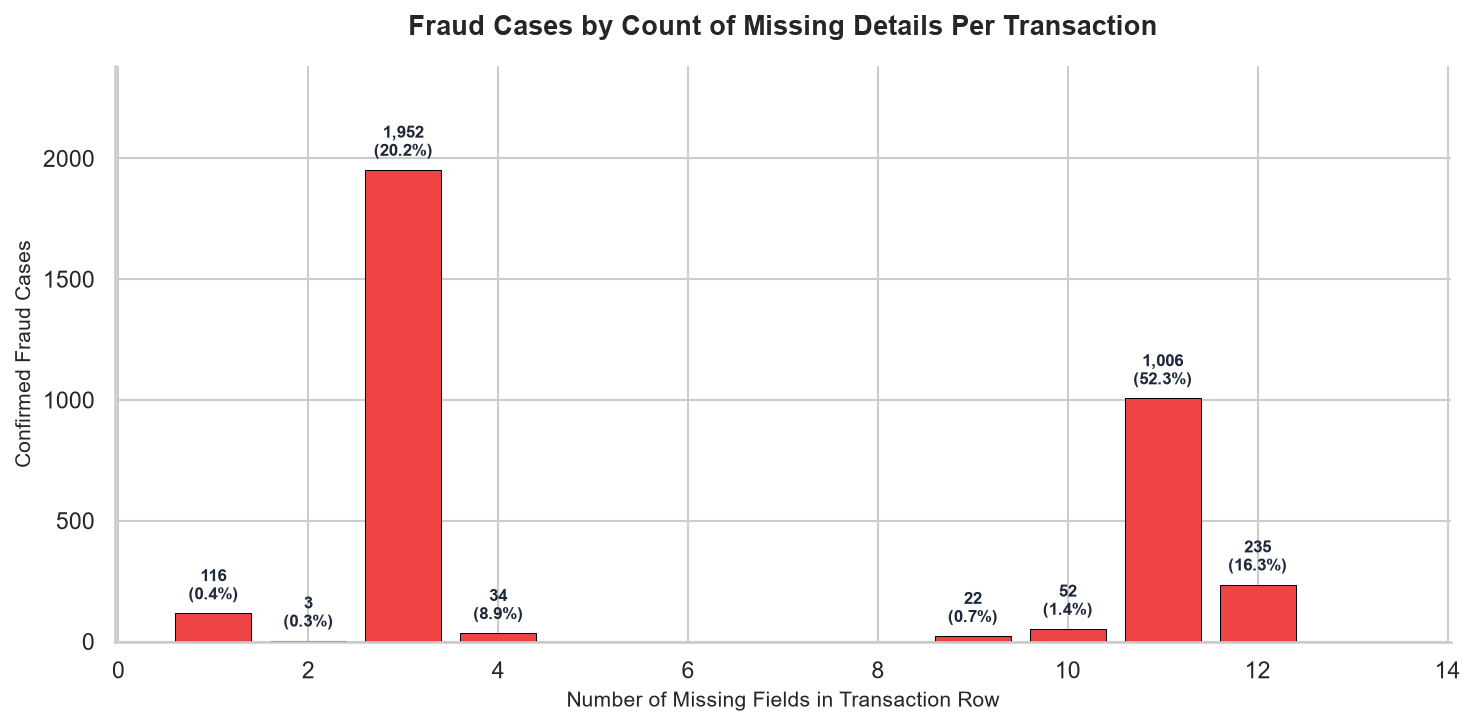

 Most Incomplete Fraudulent Transaction has 12 missing attributes.


In [45]:
# Calculate total missing attributes per transaction row
fraud_data['total_missing_fields'] = fraud_data.isnull().sum(axis=1)

# Group by missing count and calculate fraud stats
missing_density = fraud_data.groupby('total_missing_fields')['fraud'].agg(
    Total_Txns=('count'),
    Fraud_Txns=('sum'),
    Fraud_Rate=('mean')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

# Plot bar chart for total missing fields colored by Fraud Rate
bars = ax.bar(
    x=missing_density['total_missing_fields'],
    height=missing_density['Fraud_Txns'],
    color='#EF4444',
    edgecolor='black',
    linewidth=0.5
)

# Overlay data labels showing (Fraud Count / Fraud Rate %)
for bar, rate, tot in zip(bars, missing_density['Fraud_Rate'], missing_density['Total_Txns']):
    h = bar.get_height()
    if h > 0:
        ax.text(
            x=bar.get_x() + bar.get_width() / 2,
            y=h + (missing_density['Fraud_Txns'].max() * 0.02),
            s=f"{int(h):,}\n({rate*100:.1f}%)",
            ha='center', va='bottom', fontsize=8, fontweight='bold', color='#1E293B'
        )

ax.set_title('Fraud Cases by Count of Missing Details Per Transaction', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Number of Missing Fields in Transaction Row', fontsize=10)
ax.set_ylabel('Confirmed Fraud Cases', fontsize=10)
ax.set_ylim(0, missing_density['Fraud_Txns'].max() * 1.22)
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

# Print top incomplete fraudulent transactions dataframe sample
top_missing_fraud = fraud_data[fraud_data['fraud'] == 1].sort_values(
    by='total_missing_fields', ascending=False
)
print(f" Most Incomplete Fraudulent Transaction has {top_missing_fraud['total_missing_fields'].max()} missing attributes.")

 MISSING VARIABLE BREAKDOWN IN FRAUDULENT TRANSACTIONS
           Variable  Fraud_Missing_Count Fraud_Missing_Pct Legit_Missing_Pct Fraud_Rate_When_Missing
               uuid                 3420           100.00%           100.00%                   6.40%
 lut_last_paid_date                 3227            94.36%            20.38%                  24.05%
lut_first_paid_date                 3227            94.36%            20.38%                  24.05%
                 ip                 1315            38.45%            17.78%                  12.88%
            browser                 1315            38.45%            17.78%                  12.88%
          loginTime                 1315            38.45%            17.78%                  12.88%
           latitude                 1315            38.45%            17.78%                  12.88%
                isp                 1315            38.45%            17.78%                  12.88%
          longitude                 

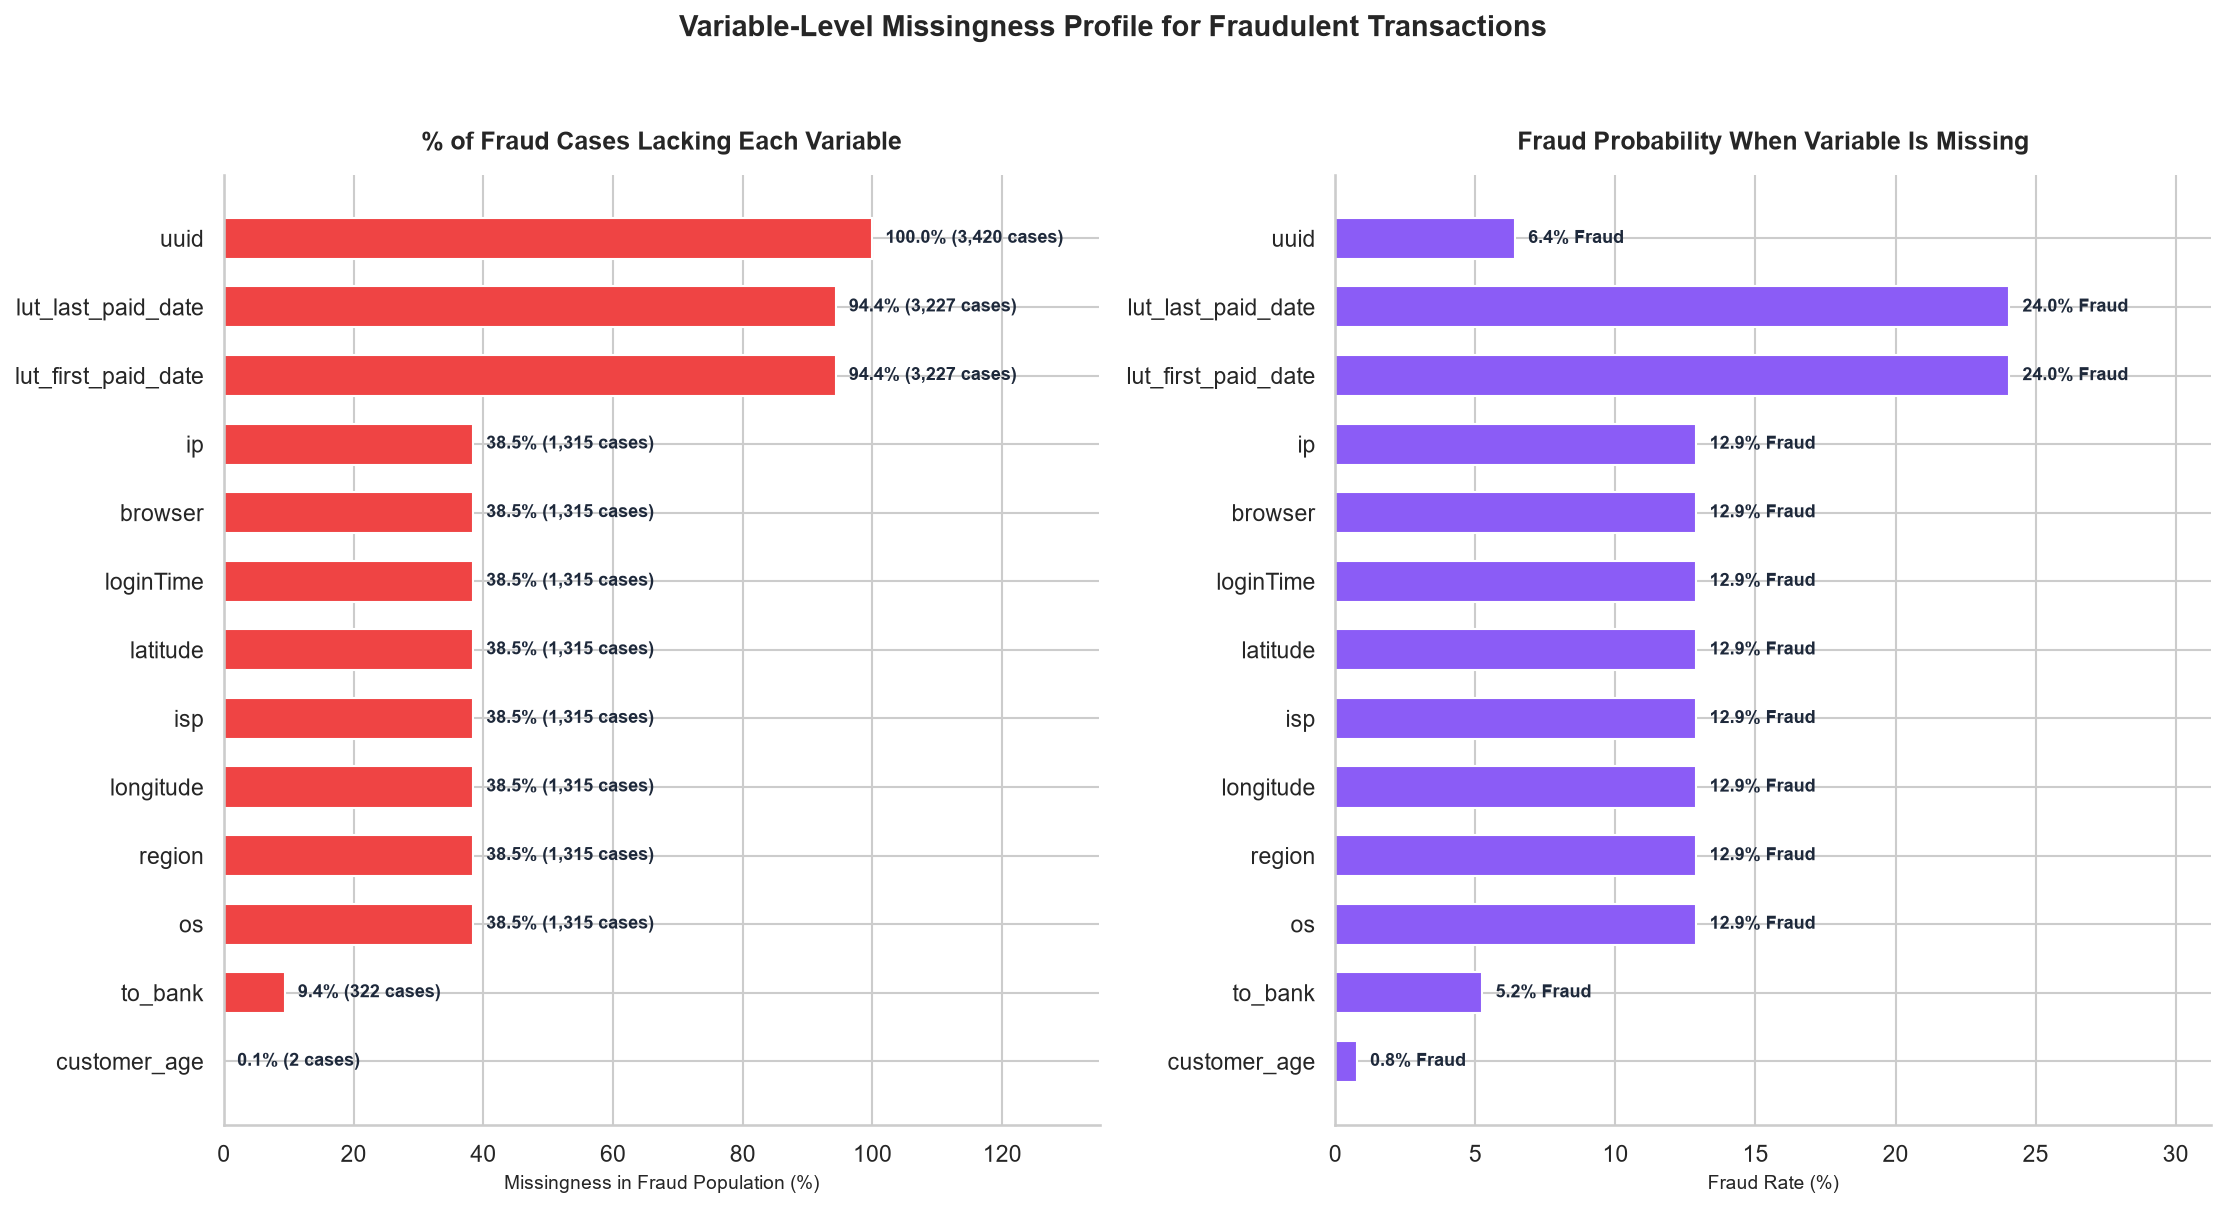

In [46]:
# Set clean visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 150

# Filter dataset for confirmed fraud cases only
fraud_only = fraud_data[fraud_data['fraud'] == 1]
legit_only = fraud_data[fraud_data['fraud'] == 0]

# -------------------------------------------------------------------
# 1. CALCULATE MISSING VARIABLE METRICS
# -------------------------------------------------------------------
missing_stats = []

for col in fraud_data.columns:
    if col in ['fraud', 'total_missing_fields', 'timestamp_missing', 'txn_datetime']:
        continue
        
    fraud_null_cnt = fraud_only[col].isnull().sum()
    fraud_null_pct = (fraud_null_cnt / len(fraud_only)) * 100
    
    legit_null_cnt = legit_only[col].isnull().sum()
    legit_null_pct = (legit_null_cnt / len(legit_only)) * 100
    
    # Calculate fraud rate when this specific variable IS missing
    missing_mask = fraud_data[col].isnull()
    fraud_rate_when_missing = (fraud_data[missing_mask]['fraud'].mean() * 100) if missing_mask.sum() > 0 else 0.0
    
    if fraud_null_cnt > 0:
        missing_stats.append({
            'Variable': col,
            'Fraud_Missing_Count': fraud_null_cnt,
            'Fraud_Missing_Pct': fraud_null_pct,
            'Legit_Missing_Pct': legit_null_pct,
            'Fraud_Rate_When_Missing': fraud_rate_when_missing
        })

# Convert to DataFrame
fraud_missing_df = pd.DataFrame(missing_stats).sort_values(by='Fraud_Missing_Pct', ascending=False)

# -------------------------------------------------------------------
# 2. DISPLAY SUMMARY TABLE
# -------------------------------------------------------------------
if fraud_missing_df.empty:
    print("There are no missing values in any variables within the fraudulent transactions!")
else:
    print("=" * 75)
    print(" MISSING VARIABLE BREAKDOWN IN FRAUDULENT TRANSACTIONS")
    print("=" * 75)
    print(fraud_missing_df.to_string(index=False, formatters={
        'Fraud_Missing_Pct': '{:.2f}%'.format,
        'Legit_Missing_Pct': '{:.2f}%'.format,
        'Fraud_Rate_When_Missing': '{:.2f}%'.format
    }))
    print("=" * 75)

    # -------------------------------------------------------------------
    # 3. VISUALIZATION: MISSINGNESS COMPARISON (FRAUD VS LEGIT)
    # -------------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(15, max(4, len(fraud_missing_df) * 0.6)))

    # Plot 1: % of Fraud Cases Missing Variable
    bars1 = axes[0].barh(
        y=fraud_missing_df['Variable'],
        width=fraud_missing_df['Fraud_Missing_Pct'],
        color='#EF4444',
        height=0.6
    )
    
    max_w1 = fraud_missing_df['Fraud_Missing_Pct'].max()
    for bar, cnt in zip(bars1, fraud_missing_df['Fraud_Missing_Count']):
        w = bar.get_width()
        axes[0].text(
            x=w + (max_w1 * 0.02),
            y=bar.get_y() + bar.get_height() / 2,
            s=f"{w:.1f}% ({cnt:,} cases)",
            va='center', fontsize=8.5, fontweight='bold', color='#1E293B'
        )

    axes[0].set_title('% of Fraud Cases Lacking Each Variable', fontsize=12, fontweight='bold', pad=12)
    axes[0].set_xlabel('Missingness in Fraud Population (%)', fontsize=9)
    axes[0].set_xlim(0, max_w1 * 1.35)
    axes[0].invert_yaxis()
    sns.despine(ax=axes[0], top=True, right=True)

    # Plot 2: Fraud Rate when Variable IS Missing
    bars2 = axes[1].barh(
        y=fraud_missing_df['Variable'],
        width=fraud_missing_df['Fraud_Rate_When_Missing'],
        color='#8B5CF6',
        height=0.6
    )
    
    max_w2 = fraud_missing_df['Fraud_Rate_When_Missing'].max()
    for bar in bars2:
        w = bar.get_width()
        axes[1].text(
            x=w + (max_w2 * 0.02),
            y=bar.get_y() + bar.get_height() / 2,
            s=f"{w:.1f}% Fraud",
            va='center', fontsize=8.5, fontweight='bold', color='#1E293B'
        )

    axes[1].set_title('Fraud Probability When Variable Is Missing', fontsize=12, fontweight='bold', pad=12)
    axes[1].set_xlabel('Fraud Rate (%)', fontsize=9)
    axes[1].set_ylabel('')
    axes[1].set_xlim(0, max_w2 * 1.3)
    axes[1].invert_yaxis()
    sns.despine(ax=axes[1], top=True, right=True)

    plt.suptitle('Variable-Level Missingness Profile for Fraudulent Transactions', fontsize=14, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.show()